# Data Setting

### Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import os
import glob

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스

import warnings

# 불필요한 경고 메시지를 숨깁니다.
warnings.filterwarnings('ignore', category=FutureWarning)

### Load data

In [2]:
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = './Data'

# CSV 파일 검색
all_file_list = glob.glob(os.path.join(path, '20*.csv'))
exclude_file_list = ['./Data/2025.csv', './Data/2025_hs.csv']
file_list = [f for f in all_file_list if f not in exclude_file_list]

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

df = df_combined.copy()

찾은 CSV 파일 개수: 7
파일 목록: ['./Data/2022.csv', './Data/2018.csv', './Data/2019.csv', './Data/2020.csv', './Data/2021.csv', './Data/2024.csv', './Data/2023.csv']

통합된 데이터프레임 크기: (3557756, 23)


### Data Structure

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557756 entries, 0 to 3557755
Data columns (total 23 columns):
 #   Column   Dtype  
---  ------   -----  
 0   접수년도     int64  
 1   자치구코드    int64  
 2   자치구명     object 
 3   법정동코드    int64  
 4   법정동명     object 
 5   지번구분코드   float64
 6   지번구분     object 
 7   본번       float64
 8   부번       float64
 9   층        float64
 10  계약일      int64  
 11  전월세구분    object 
 12  임대면적     float64
 13  보증금(만원)  int64  
 14  임대료(만원)  int64  
 15  건물명      object 
 16  건축년도     float64
 17  건물용도     object 
 18  계약기간     object 
 19  신규계약구분   object 
 20  갱신청구권사용  object 
 21  종전보증금    float64
 22  종전임대료    float64
dtypes: float64(8), int64(6), object(9)
memory usage: 624.3+ MB


In [4]:
print(np.sort(df['접수년도'].unique()))

[2018 2019 2020 2021 2022 2023 2024]


In [5]:
print("--- DataFrame의 실제 컬럼명 ---")
print(df.columns)

--- DataFrame의 실제 컬럼명 ---
Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료'],
      dtype='object')


In [6]:
print(df.head(5))

   접수년도  자치구코드  자치구명  법정동코드   법정동명  지번구분코드 지번구분     본번    부번     층  ...  \
0  2022  11560  영등포구  12600  양평동2가     1.0   대지    1.0   3.0   6.0  ...   
1  2022  11560  영등포구  11800    도림동     NaN  NaN    NaN   NaN   NaN  ...   
2  2022  11215   광진구  10700    화양동     1.0   대지  111.0  12.0  19.0  ...   
3  2022  11620   관악구  10100    봉천동     NaN  NaN    NaN   NaN   NaN  ...   
4  2022  11620   관악구  10100    봉천동     NaN  NaN    NaN   NaN   NaN  ...   

   보증금(만원) 임대료(만원)   건물명    건축년도   건물용도         계약기간  신규계약구분 갱신청구권사용 종전보증금  \
0    16000       0  힘멜하임  2014.0   오피스텔  22.01~24.01      신규     NaN   0.0   
1      300      30   NaN  1986.0  단독다가구          NaN     NaN     NaN   NaN   
2    10000     135   NaN  2021.0   오피스텔  22.01~24.01      신규     NaN   0.0   
3     4000      40   NaN  2019.0  단독다가구  22.02~23.02      신규     NaN   0.0   
4    13000       0   NaN  2019.0  단독다가구  22.01~24.01      신규     NaN   0.0   

  종전임대료  
0   NaN  
1   NaN  
2   0.0  
3   0.0  
4   NaN  

[5 rows x 23 column

## Data Cleaning & Preparation

In [7]:
# 필요한 데이터 선택
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도']
df = df[selected_columns]
print(df.tail(3))

         접수년도 자치구명   법정동명 전월세구분    임대면적  보증금(만원)  임대료(만원)   건물용도
3557753  2023   중구  남산동2가    전세  104.85    38000        0  단독다가구
3557754  2023  종로구    청운동    전세  123.36    60000        0  단독다가구
3557755  2023  광진구    광장동    전세  138.99   105000        0  단독다가구


In [8]:
# 법정동명 확인
#print(df['법정동명'].unique())

# 원하는 동이 있는지 확인
target_dong = '합정동'
if target_dong in df['법정동명'].values:
    print(f"'{target_dong}' 동이 데이터에 존재합니다.")
else:
    print(f"'{target_dong}' 동이 데이터에 존재하지 않습니다.")

'합정동' 동이 데이터에 존재합니다.


In [9]:
# 결측치 및 이상치 처리
print(df.isnull().sum())
df = df.dropna()
df = df[df['임대면적'] > 0]

접수년도       0
자치구명       0
법정동명       0
전월세구분      9
임대면적       0
보증금(만원)    0
임대료(만원)    0
건물용도       0
dtype: int64


### 임대면적 분포

Text(0.5, 1.0, '임대면적 분포')

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48516 (\N

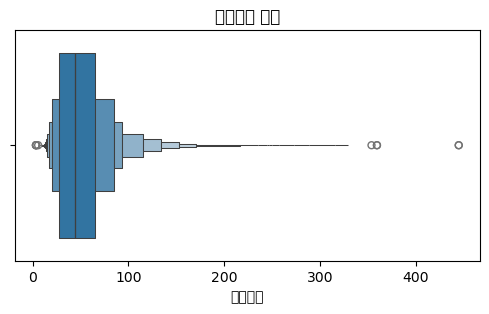

In [10]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포')

Text(0.5, 1.0, '임대면적 분포 (이상치 제거 후)')

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48516 (\N

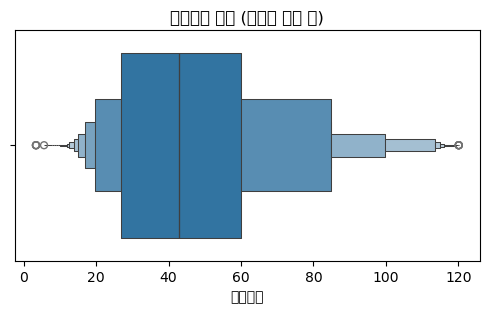

In [11]:
# 이상치 제거
q1 = df['임대면적'].quantile(0.25)
q3 = df['임대면적'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['임대면적'] >= lower_bound) & (df['임대면적'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포 (이상치 제거 후)')

### 입대료 분포


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uo

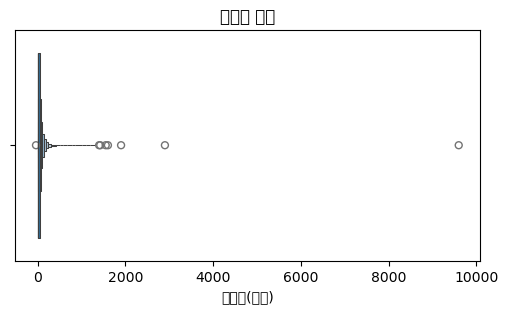

In [12]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포')
plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uo

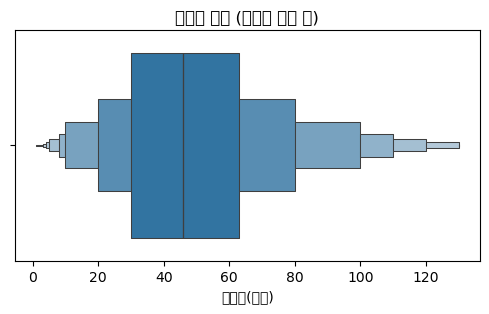

In [13]:
# 음수 및 임대료가 없는 경우 제거
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포 (이상치 제거 후)')
plt.show()

### 보증금 분포

Text(0.5, 1.0, '보증금 분포')

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 54252 (\N

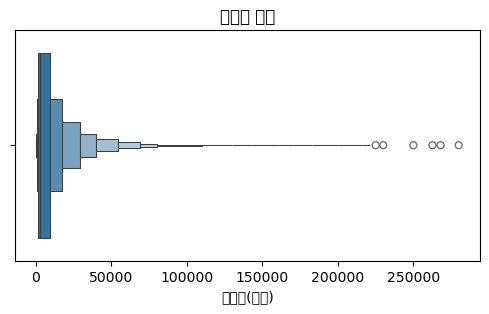

In [14]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포')

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs

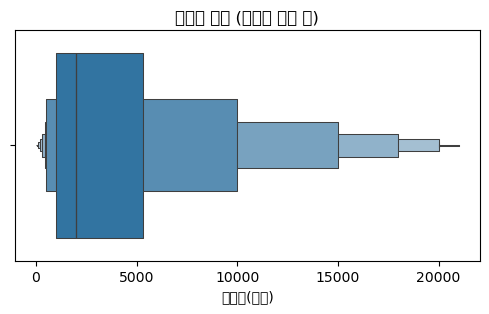

In [15]:
# 음수 보증금 제거
df = df[df['보증금(만원)'] > 0]


# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포 (이상치 제거 후)')
plt.show()

## Feature Engineering

### 단위면적당 월세

월세 가격을 공정하게 비교하기 위해 표준화 작업을 실시
- 월세를 면적으로 나누어 1제곱미터 당 가격 계산

In [16]:
# 단위면적당 월세 계산
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 무한대 및 NaN 값 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료!")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

'단위면적당_월세' 컬럼 생성 완료!
    임대면적  임대료(만원)  단위면적당_월세
1  20.00       30  1.500000
3  18.50       40  2.162162
5  15.96        6  0.375940
6  15.00       40  2.666667
7  18.50       40  2.162162


### 대학가 컬럼 생성

In [17]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. '대학가'라는 새로운 컬럼을 생성
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df[df['대학가'] != ''].copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_analysis.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(df_analysis['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 (상위 5개) ---")
# '법정동명'이 '대학가'에 잘 매칭되었는지 확인
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head())

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 162752 entries, 3 to 3557741
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   접수년도      162752 non-null  int64  
 1   자치구명      162752 non-null  object 
 2   법정동명      162752 non-null  object 
 3   전월세구분     162752 non-null  object 
 4   임대면적      162752 non-null  float64
 5   보증금(만원)   162752 non-null  int64  
 6   임대료(만원)   162752 non-null  int64  
 7   건물용도      162752 non-null  object 
 8   단위면적당_월세  162752 non-null  float64
 9   대학가       162752 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 13.7+ MB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      112891
서울시립대     24869
서울교대      12589
홍익대       12403
Name: count, dtype: int64

--- 최종 데이터 샘플 (상위 5개) ---
   자치구명 법정동명  대학가  단위면적당_월세
3   관악구  봉천동  서울대  2.162162
5   관악구  봉천동  서울대  0.375940
13  관악구  봉천동  서울대  2.150000
18  관악구  신림동  서

# EDA

### 대학가별 단위면적당 월세 분포 확인

In [18]:
print(df_analysis['대학가'].value_counts())

대학가
서울대      112891
서울시립대     24869
서울교대      12589
홍익대       12403
Name: count, dtype: int64


In [19]:
# '단위면적당_월세'의 기술 통계량 확인
print(df_analysis['단위면적당_월세'].describe())

count    162752.000000
mean          1.850590
std           1.086152
min           0.014215
25%           1.001603
50%           1.750000
75%           2.500000
max          12.054507
Name: 단위면적당_월세, dtype: float64


### Correlation Plot

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) D

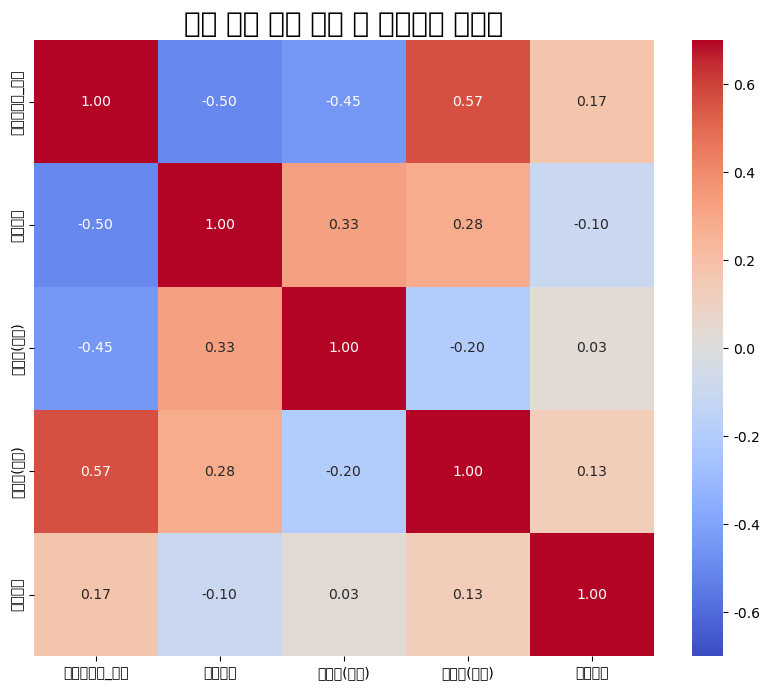

In [20]:
# 1. 수치형 변수 선택
numerical_cols = ['단위면적당_월세', '임대면적', '보증금(만원)', '임대료(만원)', '접수년도']
correlation_data = df_analysis[numerical_cols]

# 2. 상관 행렬 계산
correlation_matrix = correlation_data.corr()

# 3. 히트맵으로 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-0.7, vmax=0.7)
plt.title('월세 관련 주요 변수 간 상관관계 히트맵', fontsize=20)
plt.show()

### 대학가별 단위면적당 월세 분포 Violin Plot

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE 

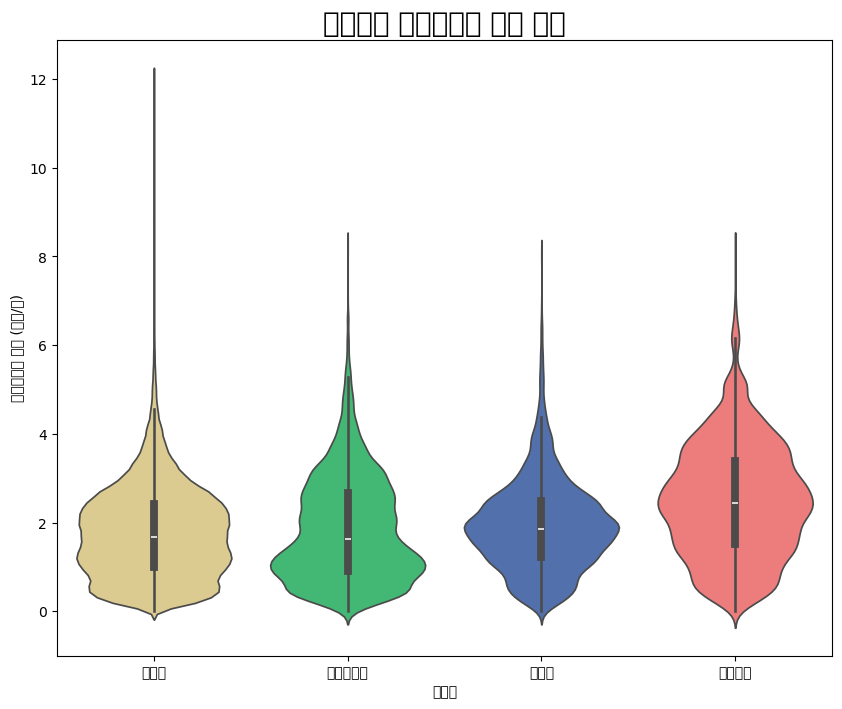

In [21]:
# plotting
plt.figure(figsize=(10, 8))
sns.violinplot(x='대학가', y='단위면적당_월세', data=df_analysis, 
               palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'])
plt.title('대학가별 단위면적당 월세 분포', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('단위면적당 월세 (만원/㎡)')
plt.show()

### 평균비교

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  

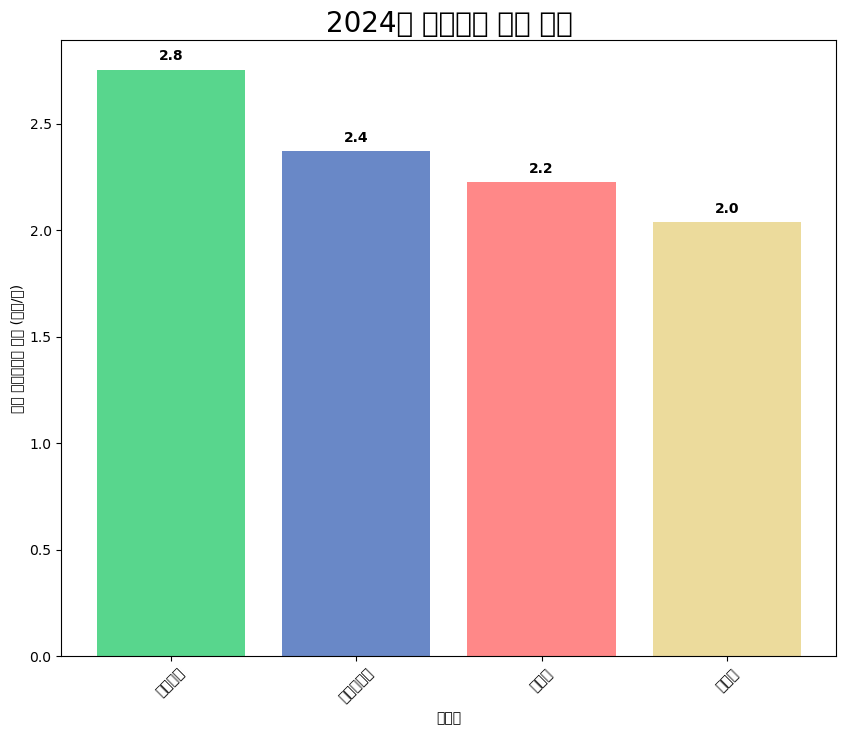

In [22]:
# 2024년 데이터 만 필터링
df_all_univ_2024 = df_analysis[df_analysis['접수년도'] == 2024]

# 평균 비교 막대그래프
plt.figure(figsize=(10, 8))
mean_by_univ = df_all_univ_2024.groupby('대학가')['단위면적당_월세'].mean().sort_values(ascending=False)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(mean_by_univ.index, mean_by_univ.values, color=['#2ECC71', '#436BBA', '#FF6B6B', '#E8D284'], alpha=0.8)
plt.title('2024년 대학가별 평균 월세', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.xticks(rotation=45)

# 막대 위에 수치 표시
for bar, value in zip(bars, mean_by_univ.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.show()


## 신뢰도 분석

### Bootstrap

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/774284907.py:32: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/774284907.py:32: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/774284907.py:32: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/774284907.py:32: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

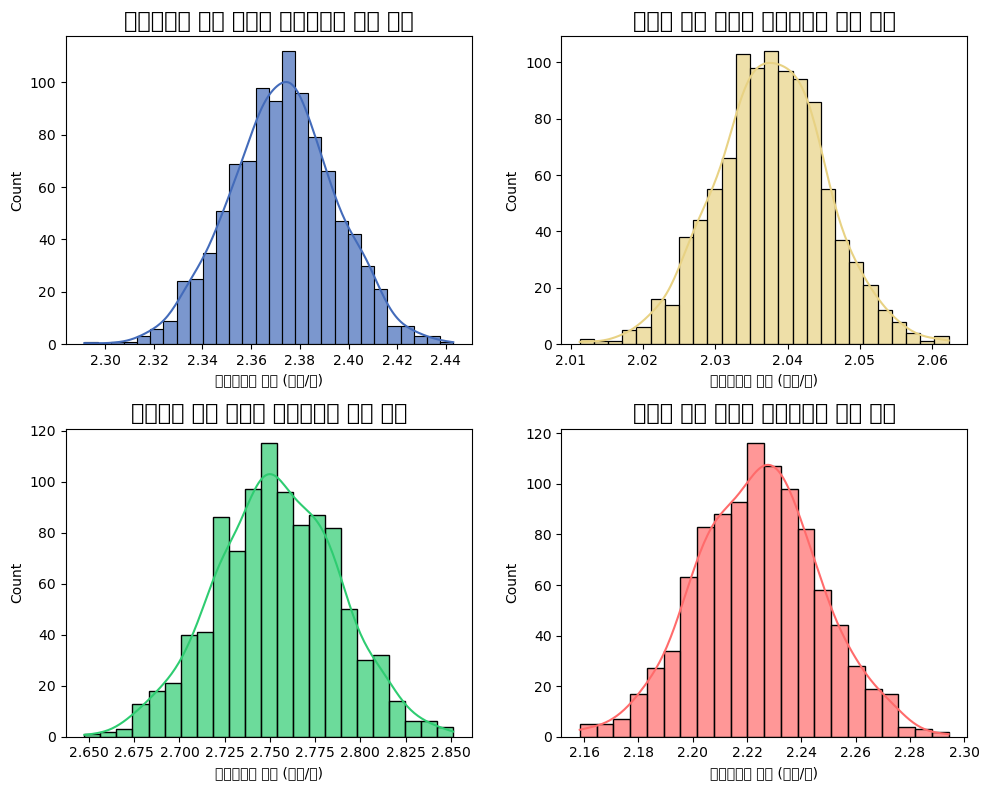

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.

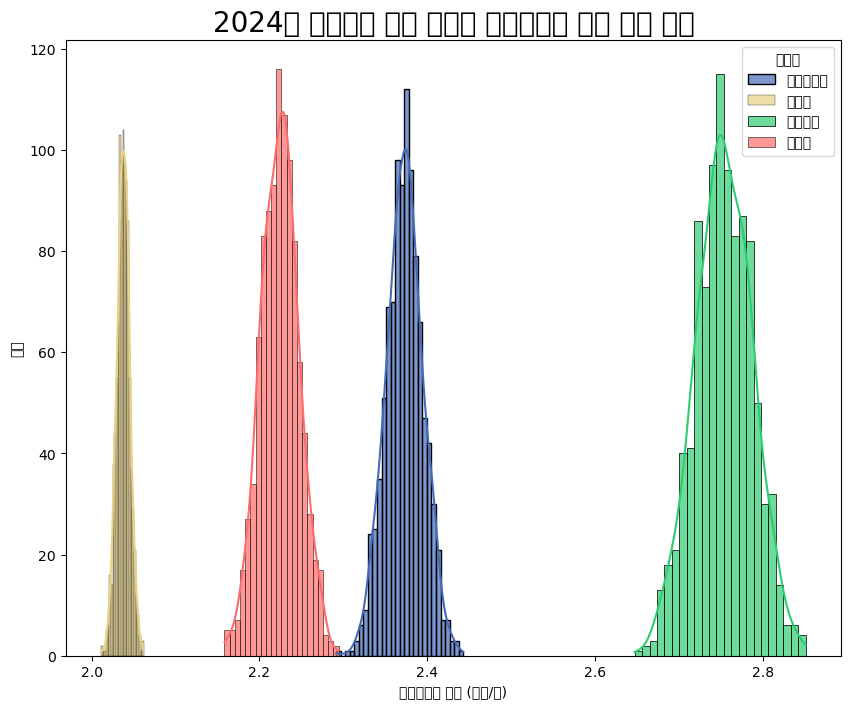

In [23]:
# 2024년 각 대학가별 데이터 분리
df_seoul_city_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울시립대']
df_seoul_nat_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울대']
df_seoul_edu_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울교대']
df_hongik_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '홍익대']

# 모든 대학가에 대해 부트스트랩 수행
universities = ['서울시립대', '서울대', '서울교대', '홍익대']
datasets = [df_seoul_city_2024, df_seoul_nat_2024, 
            df_seoul_edu_2024, df_hongik_2024]
bootstrap_results = {}

for univ, data in zip(universities, datasets):
    bootstrap_means = []
    for _ in range(1000):
        sample = data['단위면적당_월세'].sample(n=len(data), replace=True)
        bootstrap_means.append(sample.mean())
    bootstrap_results[univ] = bootstrap_means

# 시각화
plt.figure(figsize=(10, 8))

colors=['#436BBA', '#E8D284', '#2ECC71', '#FF6B6B']

# 개별 대학가별 부트스트랩 분포
for i, (univ, color) in enumerate(zip(universities, colors)):
    plt.subplot(2, 2, i+1)
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, color=color)
    plt.title(f'{univ} 월세 평균의 부트스트랩 표본 분포', fontsize=16)
    plt.xlabel('단위면적당 월세 (만원/㎡)')

plt.tight_layout()
plt.show()

# 모든 대학가 부트스트랩 결과를 하나의 그래프로 비교
plt.figure(figsize=(10, 8))

for univ, color in zip(universities, colors):
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, label=univ, color=color)

plt.title('2024년 대학가별 월세 평균의 부트스트랩 표본 분포 비교', fontsize=20)
plt.xlabel('단위면적당 월세 (만원/㎡)')
plt.ylabel('빈도')
plt.legend(title='대학가')
plt.show()

### 각 대학별 95% 신뢰구간 계산

In [24]:
for univ in universities:
    bootstrap_means_univ = bootstrap_results[univ]
    
    # 95% 신뢰구간 계산
    lower_bound = np.percentile(bootstrap_means_univ, 2.5)
    upper_bound = np.percentile(bootstrap_means_univ, 97.5)
    
    # 표준오차 계산
    std_error = np.std(bootstrap_means_univ)
    
    # 평균 계산
    mean_val = np.mean(bootstrap_means_univ)
    
    print(f"=== {univ} ===")
    print(f"단위면적당 월세 평균: {mean_val:.2f} 만원")
    print(f"95% 신뢰구간: [{lower_bound:.2f}, {upper_bound:.2f}] 만원")
    print(f"표준오차: {std_error:.2f} 만원")
    print()

=== 서울시립대 ===
단위면적당 월세 평균: 2.37 만원
95% 신뢰구간: [2.33, 2.42] 만원
표준오차: 0.02 만원

=== 서울대 ===
단위면적당 월세 평균: 2.04 만원
95% 신뢰구간: [2.02, 2.05] 만원
표준오차: 0.01 만원

=== 서울교대 ===
단위면적당 월세 평균: 2.75 만원
95% 신뢰구간: [2.69, 2.82] 만원
표준오차: 0.03 만원

=== 홍익대 ===
단위면적당 월세 평균: 2.22 만원
95% 신뢰구간: [2.18, 2.27] 만원
표준오차: 0.02 만원



### QQ plot

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/2572045185.py:14: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2572045185.py:14: UserWarning: Glyph 47200 (\N{HANGUL SYLLABLE RON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2572045185.py:14: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2572045185.py:14: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2572045185.py:14: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2572045185.py:14: UserWarni

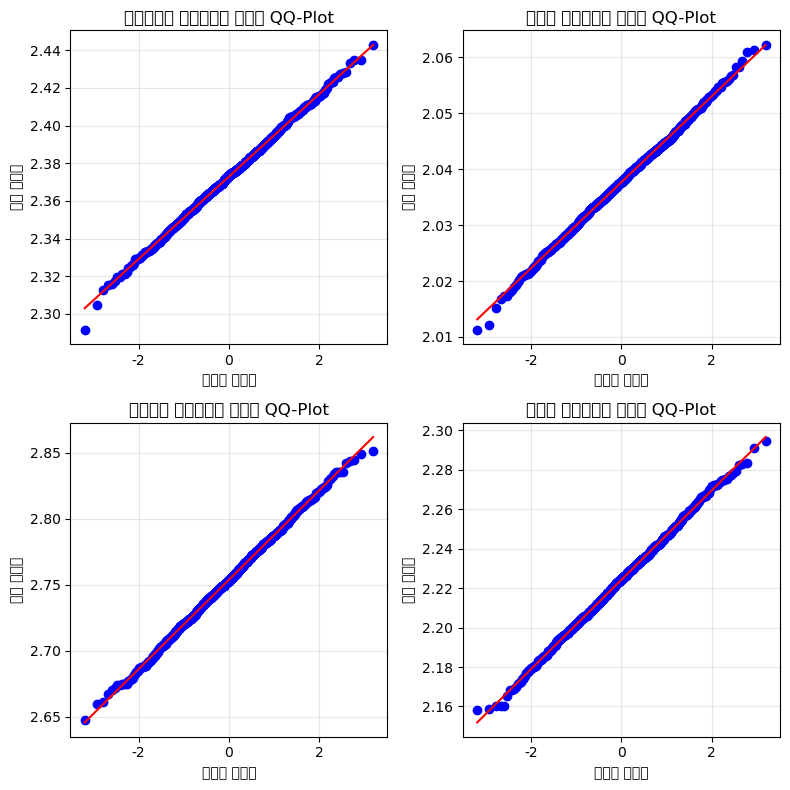

In [25]:
from scipy import stats

plt.figure(figsize=(8, 8))

# 각 대학가별 QQ-Plot
for i, univ in enumerate(universities):
    plt.subplot(2, 2, i+1)
    stats.probplot(bootstrap_results[univ], dist="norm", plot=plt)
    plt.title(f'{univ} 부트스트랩 평균의 QQ-Plot')
    plt.xlabel('이론적 분위수')
    plt.ylabel('표본 분위수')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 연도별 대학가 단위면적당 월세 변화 분석

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.p

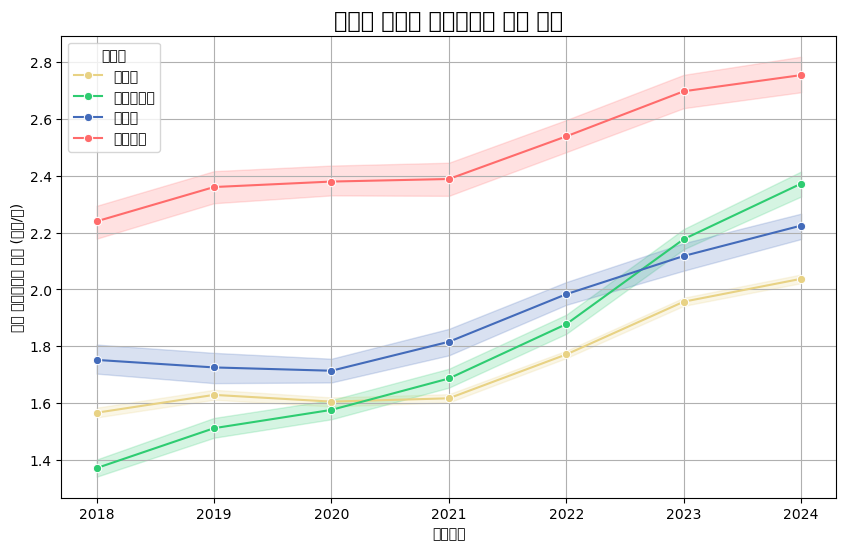

In [26]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='접수년도', y='단위면적당_월세', hue='대학가', data=df_analysis, estimator=np.mean, palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'], marker='o')
plt.title('연도별 대학가 단위면적당 월세 추이', fontsize=16)
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.grid(True)
plt.show()

### 월세 증가율

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python

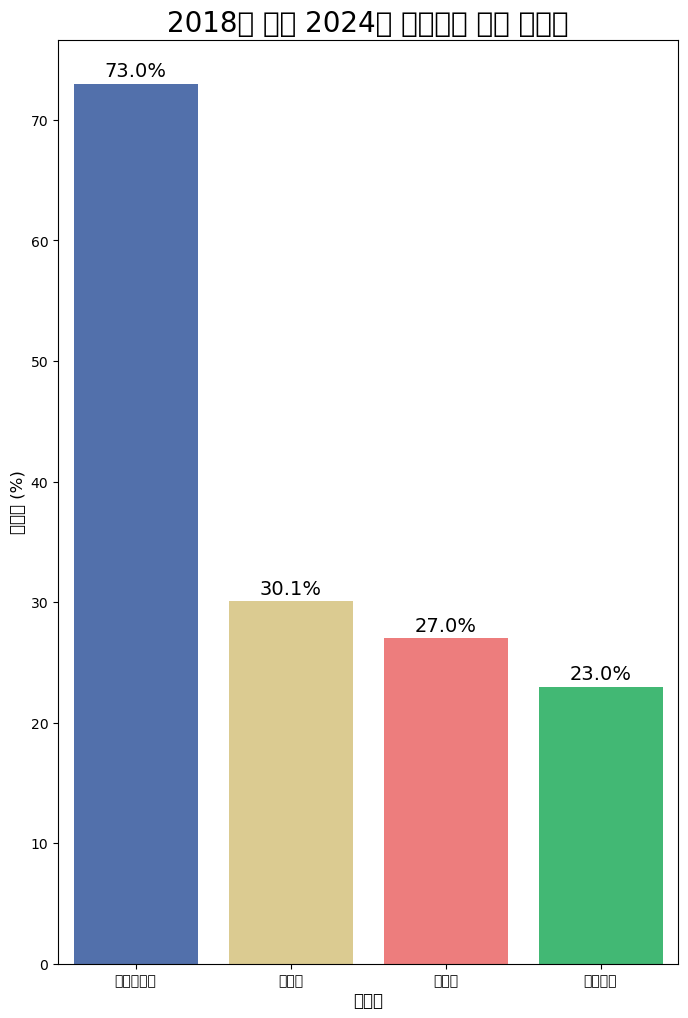

In [27]:
# 1. 증가율 계산
start_year = df_analysis['접수년도'].min()
end_year = df_analysis['접수년도'].max()

rent_start = df_analysis[df_analysis['접수년도'] == start_year].groupby('대학가')['단위면적당_월세'].mean()
rent_end = df_analysis[df_analysis['접수년도'] == end_year].groupby('대학가')['단위면적당_월세'].mean()

increase_rate = ((rent_end - rent_start) / rent_start) * 100

# 2. 증가율을 내림차순으로 정렬
sorted_increase_rate = increase_rate.sort_values(ascending=False)

# 3. 막대그래프로 시각화
plt.figure(figsize=(8, 12))
ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette=['#436BBA', '#E8D284', '#FF6B6B', '#2ECC71'])

# 그래프 제목 및 축 레이블 설정
plt.title(f'{start_year}년 대비 {end_year}년 대학가별 월세 증가율', fontsize=20)
plt.ylabel('증가율 (%)', fontsize=12)
plt.xlabel('대학가', fontsize=12)
plt.xticks(rotation=0)

# 막대 위에 퍼센트 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',    # 표시할 텍스트
                (p.get_x() + p.get_width() / 2., p.get_height()), # 텍스트 위치
                ha='center', va='center',   # 정렬
                xytext=(0, 9),              # 막대 끝에서 약간 위로
                textcoords='offset points',
                fontsize=14)                
plt.show()

# Hypothesis test 

## 가설1 
: 2024년도 평균월세 차이는 과연 통계적으로 유의미한가? 

In [28]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_2024 = df_all_univ_2024.copy()

### 가설 1-A: 서울교대 vs. 서울대 (두 그룹 비교, t-test)

- 평균 월세가 가장 많이 차이나는 두 그룹을 비교

귀무가설($H_0$): $\mu_{서울교대} = \mu_{서울대}$ (두 대학가 간 평균 월세 차이가 없다.)

대립가설($H_1$): $\mu_{서울교대} > \mu_{서울대}$ (서울교대 인근 평균 월세가 더 비싸다.)

In [29]:
# --- [ 가설 1-A 검증: Independent Two-sample t-test ] ---
print("--- 🔬 가설 1-A 검증 (서울교대 vs 서울시립대) ---")

# 1. 각 그룹의 샘플 데이터를 추출
rent_snu_edu = df_2024[df_2024['대학가'] == '서울교대']['단위면적당_월세']
rent_snu = df_2024[df_2024['대학가'] == '서울시립대']['단위면적당_월세']

# 2. 등분산성 검정 (Levene's Test)
#    - p-value가 0.05보다 작으면 분산이 다르다고 가정 (equal_var=False).
levene_stat, levene_p = stats.levene(rent_snu_edu, rent_snu)
equal_var_flag = levene_p > 0.05 # True이면 등분산 가정, False이면 이분산 가정(Welch's T-test)

print(f"[등분산성 검정] p-value: {levene_p:.4f} (equal_var={equal_var_flag})")

# 3. Independent Two-sample t-test 수행
#    - alternative='greater': 서울교대(첫번째 인자)의 평균이 서울시립대(두번째 인자)보다 크다는 단측 검정
t_stat_1a, p_val_1a = stats.ttest_ind(
    rent_snu_edu, 
    rent_snu, 
    equal_var=equal_var_flag, 
    alternative='greater'
)

print(f"t-statistic: {t_stat_1a:.4f}")
print(f"p-value: {p_val_1a:.4f}")

# 4. 결과 해석
alpha = 0.05
if p_val_1a < alpha:
    print(f"▶ 결론: p-value({p_val_1a:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("   따라서, 2024년 기준 서울교대 인근의 평균 월세는 서울시립대 인근보다 통계적으로 유의미하게 비쌉니다.")
else:
    print(f"▶ 결론: p-value({p_val_1a:.4f})가 유의수준({alpha})보다 크므로 귀무가설을 기각할 수 없습니다.")
    print("   따라서, 2024년 기준 서울교대 인근의 평균 월세가 서울시립대 인근보다 유의미하게 비싸다고 말할 수 없습니다.")

--- 🔬 가설 1-A 검증 (서울교대 vs 서울시립대) ---
[등분산성 검정] p-value: 0.1697 (equal_var=True)
t-statistic: 9.5831
p-value: 0.0000
▶ 결론: p-value(0.0000)가 유의수준(0.05)보다 작으므로 귀무가설을 기각합니다.
   따라서, 2024년 기준 서울교대 인근의 평균 월세는 서울시립대 인근보다 통계적으로 유의미하게 비쌉니다.


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170

--- 📊 가설 1-A 시각화 (서울교대 vs 서울대) ---


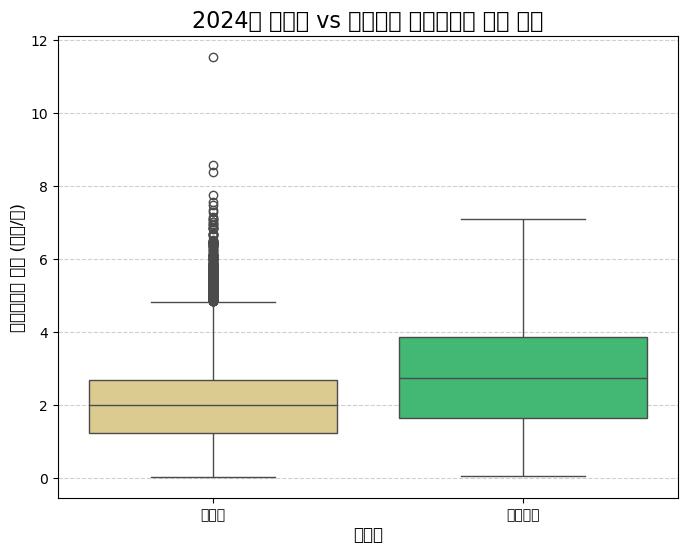

In [30]:
# --- [ 가설 1-A 시각화: Box Plot ] ---
print("--- 📊 가설 1-A 시각화 (서울교대 vs 서울대) ---")

# 1. t-test에 사용된 두 그룹('서울대', '서울교대') 데이터만 필터링
df_1a_viz = df_2024[df_2024['대학가'].isin(['서울대', '서울교대'])]

# 2. Box Plot으로 두 그룹의 분포를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='대학가', 
    y='단위면적당_월세', 
    data=df_1a_viz, 
    palette=['#E8D284', '#2ECC71'], # EDA.ipynb의 [22]번 셀 색상 팔레트와 일치
    order=['서울대', '서울교대'] # 순서 지정
)

plt.title('2024년 서울대 vs 서울교대 단위면적당 월세 분포', fontsize=16)
plt.xlabel('대학가', fontsize=12)
plt.ylabel('단위면적당 월세 (만원/㎡)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### 가설 1-B: 4개 대학가 전체 비교 (ANOVA)

귀무가설($H_0$): $\mu_{서울교대} = \mu_{서울시립대} = \mu_{서울대} = \mu_{홍익대}$ 
    (모든 대학가 간 평균 월세가 동일하다.)

대립가설($H_1$): 모든 대학가의 평균 월세가 동일한 것은 아니다. (적어도 하나는 다르다.)

In [31]:
# --- [ 가설 1-B 검증: ANOVA 및 Tukey's HSD 사후 검정 ] ---
print("\n--- 가설 1-B 검증 (4개 대학가 전체 비교) ---")

# 1. ANOVA 검증을 위해 나머지 대학가 데이터도 추출
rent_uos = df_2024[df_2024['대학가'] == '서울시립대']['단위면적당_월세']
rent_hongik = df_2024[df_2024['대학가'] == '홍익대']['단위면적당_월세']

# 2. 일원배치 분산분석 (One-way ANOVA) 수행
f_stat_1b, p_val_1b = stats.f_oneway(rent_snu_edu, rent_snu, rent_uos, rent_hongik)

print(f"[ANOVA 검증] F-statistic: {f_stat_1b:.4f}")
print(f"p-value: {p_val_1b:.4f}")

# 3. ANOVA 결과 해석
if p_val_1b < alpha:
    print(f"▶ 결론: p-value({p_val_1b:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("   따라서, 4개 대학가 간 평균 월세는 통계적으로 유의미한 차이가 있습니다.")
    print("\n   [사후 검정 (Tukey's HSD) 수행] - 어느 그룹 간에 차이가 있는지 확인합니다.")
    
    # 4. 사후 검정 (Tukey's HSD)
    #    - ANOVA가 유의미할 때만 실행하여 어떤 그룹끼리 차이가 나는지 확인
    tukey_result = pairwise_tukeyhsd(
        df_2024['단위면적당_월세'], 
        df_2024['대학가'], 
        alpha=0.05
    )
    
    print(tukey_result)
    
else:
    print(f"▶ 결론: p-value({p_val_1b:.4f})가 유의수준({alpha})보다 크므로 귀무가설을 기각할 수 없습니다.")
    print("   따라서, 4개 대학가 간 평균 월세 차이가 통계적으로 유의미하다고 말할 수 없습니다.")


--- 가설 1-B 검증 (4개 대학가 전체 비교) ---
[ANOVA 검증] F-statistic: 54.7572
p-value: 0.0000
▶ 결론: p-value(0.0000)가 유의수준(0.05)보다 작으므로 귀무가설을 기각합니다.
   따라서, 4개 대학가 간 평균 월세는 통계적으로 유의미한 차이가 있습니다.

   [사후 검정 (Tukey's HSD) 수행] - 어느 그룹 간에 차이가 있는지 확인합니다.
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  서울교대    서울대  -0.7169   0.0 -0.7901 -0.6436   True
  서울교대  서울시립대  -0.3818   0.0 -0.4661 -0.2975   True
  서울교대    홍익대  -0.5295   0.0 -0.6239 -0.4352   True
   서울대  서울시립대    0.335   0.0  0.2832  0.3869   True
   서울대    홍익대   0.1873   0.0  0.1203  0.2543   True
 서울시립대    홍익대  -0.1477   0.0 -0.2266 -0.0689   True
---------------------------------------------------


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.


--- 📊 가설 1-B 시각화 (Tukey's HSD 사후 검정) ---


/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uo

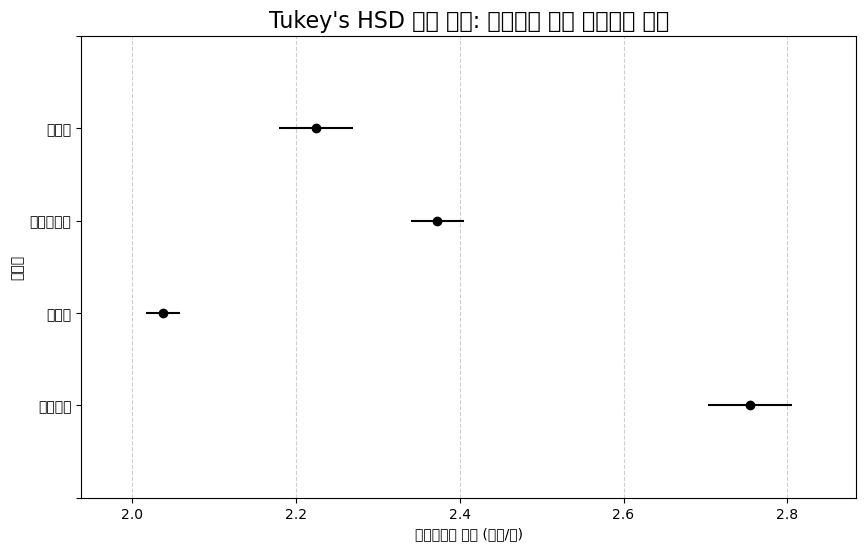

In [32]:
# --- [ 가설 1-B 시각화: Tukey's HSD Plot ] ---
print("--- 📊 가설 1-B 시각화 (Tukey's HSD 사후 검정) ---")

# 1. Tukey HSD 결과를 시각화합니다. (tukey_result 객체는 이전 셀에서 생성되어 있어야 함)
#    이 플롯은 각 그룹의 '평균'에 대한 95% 신뢰구간을 보여줍니다.
try:
    fig = tukey_result.plot_simultaneous(
        figsize=(10, 6), 
        xlabel='단위면적당 월세 (만원/㎡)',
        ylabel='대학가'
    )
    plt.title("Tukey's HSD 사후 검정: 대학가별 평균 신뢰구간 비교", fontsize=16)
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.show()

except NameError:
    print("오류: 'tukey_result' 객체가 정의되지 않았습니다. [가설 1-B] 코드를 먼저 실행하세요.")

▶ 위 결과에 따라 각 그룹 간의 차이가 모두 통계적으로 유의미한 차이임을 알 수 있다.

## 가설 2
: 서울시립대 인근의 '가파른 월세 상승' 검증

In [33]:
import statsmodels.formula.api as smf

# 전체 기간 데이터 사용
df_full = df_analysis.copy()

### 가설 2-A: 2021년 전/후 시점 비교 (A/B 테스트)

서울시립대 인근의 평균 월세는 2021년을 기점으로 통계적으로 유의미하게 상승했는가?

귀무가설($H_0$): $\mu_{2021이후} = \mu_{2021이전}$ (2021년 전후의 평균 월세 차이가 없다.)
     
대립가설($H_1$): $\mu_{2021이후} > \mu_{2021이전}$ (2021년 이후 평균 월세가 더 높다.)

In [34]:
# 간단 주석 버전
print("--- 🔬 가설 2-A 검증 (서울시립대 2021년 전/후 비교) ---")

# 서울시립대 데이터만
df_uos_full = df_full[df_full['대학가'] == '서울시립대']

# 2020년까지 = 이전, 2021년부터 = 이후
rent_pre_2021 = df_uos_full[df_uos_full['접수년도'] <= 2020]['단위면적당_월세']
rent_post_2021 = df_uos_full[df_uos_full['접수년도'] >= 2021]['단위면적당_월세']

# 등분산성 검사
levene_stat_2a, levene_p_2a = stats.levene(rent_post_2021, rent_pre_2021)
equal_var_flag_2a = levene_p_2a > 0.05
print(f"[등분산성 검정] p-value: {levene_p_2a:.4f} (equal_var={equal_var_flag_2a})")

# 단측 t-test: 이후 > 이전
t_stat_2a, p_val_2a = stats.ttest_ind(
    rent_post_2021,
    rent_pre_2021,
    equal_var=equal_var_flag_2a,
    alternative='greater'
)

print(f"t-statistic: {t_stat_2a:.4f}")
print(f"p-value: {p_val_2a:.4f}")

# 해석 (alpha는 이전 셀에서 정의한 값 사용)
if p_val_2a < alpha:
    print(f"▶ 결론: p-value({p_val_2a:.4f}) < {alpha} → 귀무가설 기각. 2021년 이후 상승이 유의미함.")
else:
    print(f"▶ 결론: p-value({p_val_2a:.4f}) >= {alpha} → 귀무가설 기각 불가. 유의한 상승 아님.")


--- 🔬 가설 2-A 검증 (서울시립대 2021년 전/후 비교) ---
[등분산성 검정] p-value: 0.0000 (equal_var=False)
t-statistic: 39.8371
p-value: 0.0000
▶ 결론: p-value(0.0000) < 0.05 → 귀무가설 기각. 2021년 이후 상승이 유의미함.


--- 📊 가설 2-A 시각화 (서울시립대 2021년 전/후) ---


/tmp/ipykernel_3100/3663711558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_uos_full['기간'] = np.where(df_uos_full['접수년도'] >= 2021, '2021년 이후', '2021년 이전')
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

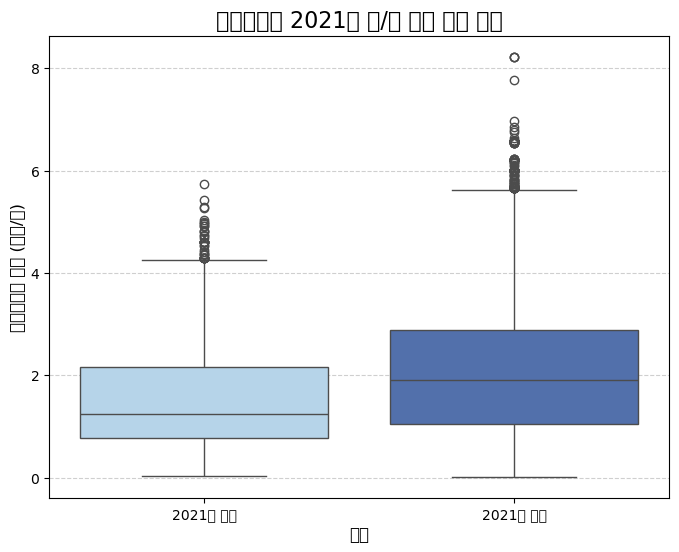

In [35]:
# --- [ 가설 2-A 시각화: Box Plot (2021년 전/후) ] ---
print("--- 📊 가설 2-A 시각화 (서울시립대 2021년 전/후) ---")

# 1. 시각화를 위해 '기간' 컬럼을 생성합니다. (df_uos_full은 이전 셀에서 생성)
df_uos_full['기간'] = np.where(df_uos_full['접수년도'] >= 2021, '2021년 이후', '2021년 이전')

# 2. Box Plot으로 두 기간의 분포를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='기간', 
    y='단위면적당_월세', 
    data=df_uos_full,
    palette=['#AED6F1', '#436BBA'], # 이전/이후 색상 지정
    order=['2021년 이전', '2021년 이후'] # 순서 지정
)

plt.title('서울시립대 2021년 전/후 월세 분포 비교', fontsize=16)
plt.xlabel('기간', fontsize=12)
plt.ylabel('단위면적당 월세 (만원/㎡)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### 가설 2-B: 타 대학가와의 '상승 추세' 비교 (회귀분석)

2021년 이후, 서울시립대 인근의 월세 상승폭은 서울대(대조군) 인근의 상승폭보다 통계적으로 유의미하게 더 컸는가?

귀무가설($H_0$): $\beta_3 = 0$ (서울시립대만의 추가적인 월세 상승 효과는 없다.)

대립가설($H_1$): $\beta_3 > 0$ (서울시립대만의 추가적인 월세 상승 효과가 유의미하게 존재한다.)

In [36]:
# --- [ 가설 2-B 검증: 회귀분석 (Difference-in-Differences) ] ---
print("\n--- 🔬 가설 2-B 검증 (서울시립대 vs 서울대 상승폭 비교) ---")

# 서울대와 서울시립대 데이터만 사용
df_did = df_full[df_full['대학가'].isin(['서울대', '서울시립대'])].copy()

# 더미 변수 생성: 2021년 이후, 서울시립대 여부
df_did['is_Post2021'] = (df_did['접수년도'] >= 2021).astype(int)
df_did['is_UOS'] = (df_did['대학가'] == '서울시립대').astype(int)

# DiD 회귀모형 (interaction 포함)
model = smf.ols(formula='단위면적당_월세 ~ is_Post2021 * is_UOS', data=df_did).fit()

# 결과 출력
print(model.summary())

# 상호작용항의 계수와 p-value 추출
interaction_term = 'is_Post2021:is_UOS'
interaction_coef = model.params[interaction_term]
interaction_pvalue = model.pvalues[interaction_term]

print(f"\n--- [ {interaction_term} ] 상호작용항 ---")
print(f"계수: {interaction_coef:.4f}")
print(f"p-value (양측): {interaction_pvalue:.4e}")

# 단측검정: 계수가 양수이고 (양측 p-value / 2) < alpha 이면 유의
p_val_one_sided = interaction_pvalue / 2

if (interaction_coef > 0) and (p_val_one_sided < alpha):
    print(f"▶ 결론: 계수 양수({interaction_coef:.4f})이고 단측 p-value({p_val_one_sided:.4e}) < {alpha} → 유의합니다.")
    print("   즉, 서울시립대의 2021년 이후 상승폭이 서울대보다 컸습니다.")
else:
    print("▶ 결론: 귀무가설을 기각할 수 없습니다. 서울시립대의 상승폭이 유의하게 더 크다고 보기 어렵습니다.")



--- 🔬 가설 2-B 검증 (서울시립대 vs 서울대 상승폭 비교) ---
                            OLS Regression Results                            
Dep. Variable:               단위면적당_월세   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1104.
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:11:12   Log-Likelihood:            -2.0080e+05
No. Observations:              137760   AIC:                         4.016e+05
Df Residuals:                  137756   BIC:                         4.017e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

▶ 회귀분석 결과, '서울시립대이면서 2021년 이후'를 나타내는 항의 계수가 +0.3057, 이 값의 p-valuerk 0.000 이다.

▶ 이는 2021년 이후 서울대, 홍익대, 서울교대 등 다른 대학가들이 공통적으로 겪은 월세 상승분(시간 효과, 0.4414)을 모두 제외하고도, 서울시립대 인근만 추가적으로 0.34 (만원/㎡)만큼 더 폭등했음을 의미

### 가설 3: 2025년 서울시립대와 홍익대 단위면적당 월세 평균 가설검정
- $\mu_{서울시립대} = \mu_{홍익대}$
- $\mu_{서울시립대} \neq \mu_{홍익대}$
- $\mu_{홍익대} - \mu_{서울시립대}$에 대해서 순열검정 구현

#### 2025년도 대학가별 단위면적당 월세 분포 확인

In [37]:
# 데이터 불러오기
df_2025 = pd.read_csv('Data/2025_hs.csv', encoding='cp949')
print(df_2025.head(3))

# 확인하고 싶은 컬럼 선택
selected_columns = ['접수연도', '자치구명', '법정동명', '전월세 구분', '임대면적(㎡)', '보증금(만원)', '임대료(만원)', '건물용도']

# 선택된 컬럼에 대한 데이터 구조 확인
target_df = df_2025[selected_columns].copy()
target_df.info()

   접수연도    자치구코드  자치구명    법정동코드   법정동명  지번구분 지번구분명     본번    부번    층  ...  \
0  2025  11560.0  영등포구  12700.0  양평동3가   1.0    대지   79.0   4.0  4.0  ...   
1  2025  11620.0   관악구  10200.0    신림동   NaN   NaN    NaN   NaN  NaN  ...   
2  2025  11500.0   강서구  10200.0    등촌동   1.0    대지  628.0  13.0  6.0  ...   

   보증금(만원) 임대료(만원)     건물명    건축년도   건물용도         계약기간  신규갱신여부 계약갱신권사용여부  \
0    41000      70    현대2차  1990.0    아파트          NaN     NaN       NaN   
1     2000     120     NaN  2016.0  단독다가구          NaN     NaN       NaN   
2     2000      45  현대프린스텔  1999.0   오피스텔  25.10~27.10      신규       NaN   

  종전 보증금 종전 임대료  
0    NaN    NaN  
1    NaN    NaN  
2    NaN    NaN  

[3 rows x 23 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445059 entries, 0 to 445058
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   접수연도     445059 non-null  int64  
 1   자치구명     445056 non-null  object 
 2   법정동명     445056 non-

접수연도       0
자치구명       3
법정동명       3
전월세 구분     0
임대면적(㎡)    0
보증금(만원)    0
임대료(만원)    0
건물용도       0
dtype: int64


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48516 (\N

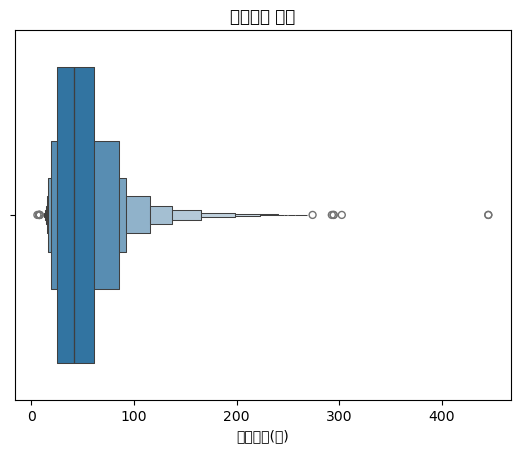

In [38]:
# 데이터 전처리
print(target_df.isnull().sum())
target_df = target_df.dropna()
target_df = target_df[target_df['임대면적(㎡)'] > 0]

sns.boxenplot(x=target_df['임대면적(㎡)'])
plt.title('임대면적 분포')
# 임대면적 이상치 제거
q1 = target_df['임대면적(㎡)'].quantile(0.25)
q3 = target_df['임대면적(㎡)'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

target_df = target_df[(target_df['임대면적(㎡)'] >= lower_bound) & (target_df['임대면적(㎡)'] <= upper_bound)]

# 음수 및 임대료가 없는 경우 제거
target_df = target_df[target_df['임대료(만원)'] > 0]

# 임대료 이상치 제거
q1 = target_df['임대료(만원)'].quantile(0.25)
q3 = target_df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

target_df = target_df[(target_df['임대료(만원)'] >= lower_bound) & (target_df['임대료(만원)'] <= upper_bound)]

# 음수 보증금 제거
target_df = target_df[target_df['보증금(만원)'] > 0]


# 보증금 이상치 제거
q1 = target_df['보증금(만원)'].quantile(0.25)
q3 = target_df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
target_df = target_df[(target_df['보증금(만원)'] >= lower_bound) & (target_df['보증금(만원)'] <= upper_bound)]


In [39]:
df = target_df.reset_index().copy()
df = df.rename(columns={'임대면적(㎡)': '임대면적'})

# 단위면적당 월세
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']
df.info()

# 계산 결과가 inf이거나 숫자가 아닌 경우는 분석에 방해가 되므로 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218382 entries, 0 to 218381
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   index     218382 non-null  int64  
 1   접수연도      218382 non-null  int64  
 2   자치구명      218382 non-null  object 
 3   법정동명      218382 non-null  object 
 4   전월세 구분    218382 non-null  object 
 5   임대면적      218382 non-null  float64
 6   보증금(만원)   218382 non-null  int64  
 7   임대료(만원)   218382 non-null  int64  
 8   건물용도      218382 non-null  object 
 9   단위면적당_월세  218382 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 16.7+ MB
'단위면적당_월세' 컬럼 생성 완료
    임대면적  임대료(만원)  단위면적당_월세
0  50.00      120  2.400000
1  21.66       45  2.077562
2  30.00       70  2.333333
3  31.80       20  0.628931
4  40.81       70  1.715266


In [40]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. 대학가 컬럼 생성
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 이름이 할당된 행들만 필터링하여 최종 분석용 데이터프레임 생성
df = df[df['대학가'] != ''].reset_index().copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df.info()

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25513 entries, 0 to 25512
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   level_0   25513 non-null  int64  
 1   index     25513 non-null  int64  
 2   접수연도      25513 non-null  int64  
 3   자치구명      25513 non-null  object 
 4   법정동명      25513 non-null  object 
 5   전월세 구분    25513 non-null  object 
 6   임대면적      25513 non-null  float64
 7   보증금(만원)   25513 non-null  int64  
 8   임대료(만원)   25513 non-null  int64  
 9   건물용도      25513 non-null  object 
 10  단위면적당_월세  25513 non-null  float64
 11  대학가       25513 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.3+ MB


In [41]:
df_uos = df[df['대학가'] == '서울시립대']
df_snu = df[df['대학가'] == '서울대']
df_snue = df[df['대학가'] == '서울교대']
df_hongik = df[df['대학가'] == '홍익대']

universities = ['서울시립대', '서울대', '서울교대', '홍익대']
datasets = [df_uos, df_snu, df_snue, df_hongik]
results = {}

for univ, data in zip(universities, datasets):
    sample_means = []
    for i in range(1000):
        sample = data['단위면적당_월세'].sample(n=len(data), replace=True)
        sample_means.append(sample.mean())
    results[univ] = sample_means

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/1003158998.py:31: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/1003158998.py:31: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/1003158998.py:31: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/1003158998.py:31: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing

서울시립대 통계량
95% 신뢰구간: [2.3756, 2.4562]
표준오차: 0.0213
표본평균의 평균: 2.4154

서울대 통계량
95% 신뢰구간: [2.1658, 2.1998]
표준오차: 0.0087
표본평균의 평균: 2.1830

서울교대 통계량
95% 신뢰구간: [2.7798, 2.9018]
표준오차: 0.0315
표본평균의 평균: 2.8424

홍익대 통계량
95% 신뢰구간: [2.2982, 2.4075]
표준오차: 0.0282
표본평균의 평균: 2.3569



/tmp/ipykernel_3100/1003158998.py:31: UserWarning: Glyph 54861 (\N{HANGUL SYLLABLE HONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/1003158998.py:31: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/en

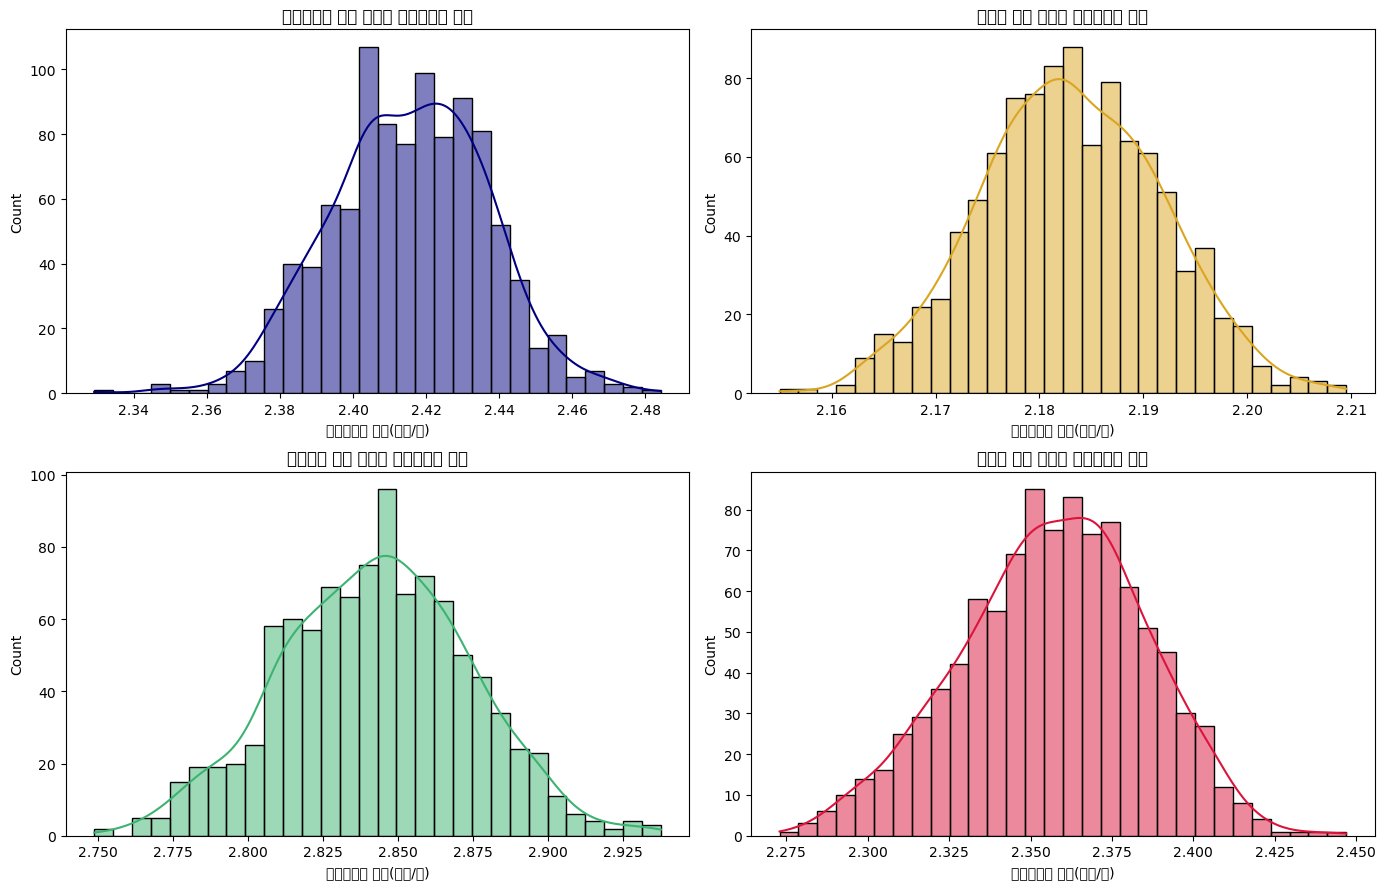

In [42]:
univ_stats = {}
colors = ['navy', 'goldenrod', 'mediumseagreen', 'crimson']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for i, (univ, sample_means) in enumerate(results.items()):
    ax = axes[i // 2, i % 2]

    sns.histplot(sample_means, kde=True, color=colors[i], ax=ax, bins=30)
    ax.set_title(f'{univ} 월세 평균의 부트스트랩 분포')
    ax.set_xlabel('단위면적당 월세(만원/㎡)')
    ax.set_ylabel('Count')

    # 95% 신뢰구간 계산
    lower_bound = np.percentile(sample_means, 2.5)
    upper_bound = np.percentile(sample_means, 97.5)

    # 표준오차 계산
    std_error = np.std(sample_means)

    # 표본평균의 평균 계산
    sample_mean = np.mean(sample_means)

    univ_stats[univ] = [(lower_bound, upper_bound), std_error, sample_mean]

    print(f'{univ} 통계량')
    print(f'95% 신뢰구간: [{lower_bound:.4f}, {upper_bound:.4f}]')
    print(f'표준오차: {std_error:.4f}')
    print(f'표본평균의 평균: {sample_mean:.4f}\n')

plt.tight_layout()
plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170

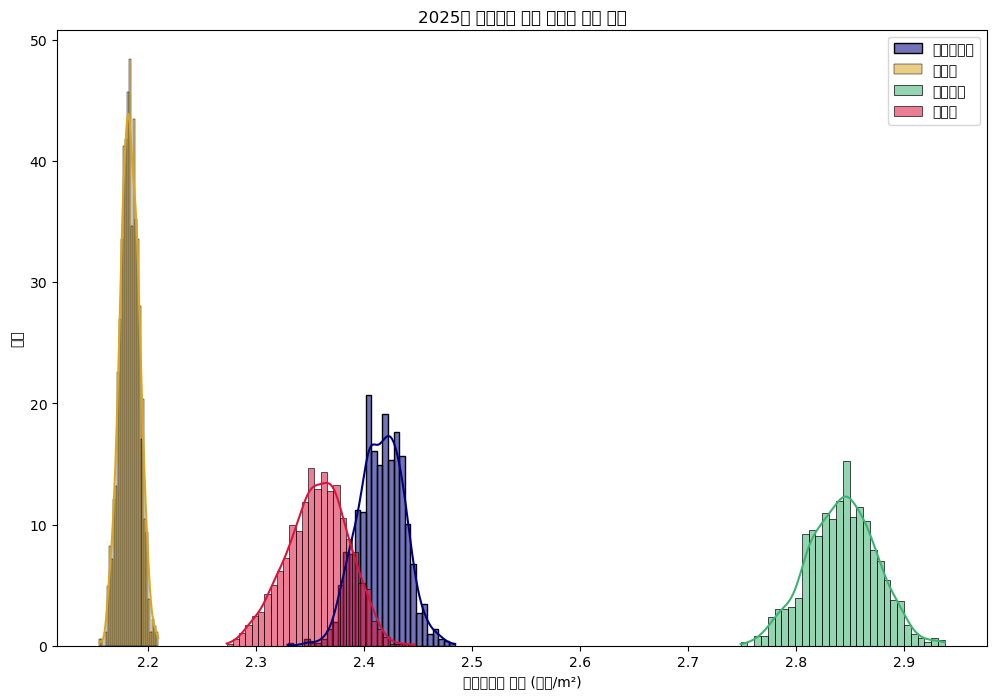

In [43]:
plt.figure(figsize=(12, 8))

for i, (univ, sample_means) in enumerate(results.items()):
    sns.histplot(sample_means, kde=True, color=colors[i], label=univ, bins=30, alpha=0.55, stat='density')
plt.legend()
plt.title('2025년 대학가별 월세 평균의 분포 비교')
plt.xlabel('단위면적당 월세 (만원/m²)')
plt.ylabel('밀도')
plt.show()


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/2217176622.py:34: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2217176622.py:34: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2217176622.py:34: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2217176622.py:34: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/2217176622.py:34: UserWarn

관측된 실제 평균 차이 (홍익대 - 서울시립대): -0.0571
순열 검정 p-value: 0.1550


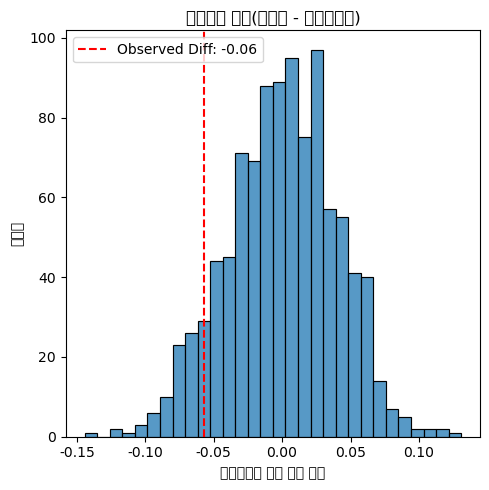

In [44]:
import random

random.seed(42)

target_df = pd.concat([df_uos['단위면적당_월세'], df_hongik['단위면적당_월세']], axis=0, ignore_index=True)
# 관측된 두 집단의 단위면적당 월세 평균 차이
obs_diff = df_hongik['단위면적당_월세'].mean() - df_uos['단위면적당_월세'].mean()

# 순열검정 통계량 생성 함수
def perm_func(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

perm_diffs = [perm_func(target_df, df_uos.shape[0], df_hongik.shape[0]) for _ in range(1000)]

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print(f"관측된 실제 평균 차이 (홍익대 - 서울시립대): {obs_diff:.4f}")
print(f"순열 검정 p-value: {p_value:.4f}")

fig, axes = plt.subplots(figsize=(5, 5))
sns.histplot(perm_diffs, bins=30, ax=axes)
axes.set_xlabel('단위면적당 월세 평균 차이')
axes.set_ylabel('빈도수')
plt.title('순열검정 결과(홍익대 - 서울시립대)')

axes.axvline(obs_diff, color='red', linestyle='--', 
             label=f'Observed Diff: {obs_diff:.2f}')
axes.legend()

plt.tight_layout()
plt.show()


### 가설 4: 2024년과 2025년의 홍익대, 서울시립대 변화 비교
- 귀무가설: $(\mu_{홍익대, 2025} - \mu_{홍익대, 2024}) = (\mu_{시립대, 2025} - \mu_{시립대, 2024}), \Delta_{홍익대} = \Delta_{시립대}$
- 대립가설: $(\mu_{홍익대, 2025} - \mu_{홍익대, 2024}) > (\mu_{시립대, 2025} - \mu_{시립대, 2024}), \Delta_{홍익대} > \Delta_{시립대}$
- 이를 통해 확인하고자 하는 것은, *"홍익대 주변 건물 임대료가 전반적으로 올랐기 때문일 것이다."* 가설에 대한 검증이다.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_2024_hs = pd.read_csv('Data/2024.csv', encoding='cp949')

# 피쳐 선택
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도']
df_2024_hs = df_2024_hs[selected_columns].copy()

target_columns = ['임대면적', '보증금(만원)', '임대료(만원)']

# 결측치 제거 & 이상치 제거
df_2024_hs = df_2024_hs.dropna()

for i, col in enumerate(target_columns):
    df_2024_hs = df_2024_hs[df_2024_hs[col] > 0]

    q1 = df_2024_hs[col].quantile(0.25)
    q3 = df_2024_hs[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_2024_hs = df_2024_hs[(df_2024_hs[col] >= lower_bound) & (df_2024_hs[col] <= upper_bound)]

df_2024_hs = df_2024_hs.reset_index().copy()

# 단위면적당 월세
df_2024_hs['단위면적당_월세'] = df_2024_hs['임대료(만원)'] / df_2024_hs['임대면적']

# 계산 결과가 inf이거나 숫자가 아닌 경우는 분석에 방해가 되므로 제거
df_2024_hs = df_2024_hs.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. 대학가 컬럼 생성
df_2024_hs['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df_2024_hs['법정동명'].isin(dong_list)
    df_2024_hs.loc[mask, '대학가'] = univ_name

# 4. '대학가' 이름이 할당된 행들만 필터링하여 최종 분석용 데이터프레임 생성
df_univ = df_2024_hs[df_2024_hs['대학가'] != ''].reset_index().copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_univ.info()


법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30302 entries, 0 to 30301
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   level_0   30302 non-null  int64  
 1   index     30302 non-null  int64  
 2   접수년도      30302 non-null  int64  
 3   자치구명      30302 non-null  object 
 4   법정동명      30302 non-null  object 
 5   전월세구분     30302 non-null  object 
 6   임대면적      30302 non-null  float64
 7   보증금(만원)   30302 non-null  int64  
 8   임대료(만원)   30302 non-null  int64  
 9   건물용도      30302 non-null  object 
 10  단위면적당_월세  30302 non-null  float64
 11  대학가       30302 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.8+ MB


In [46]:
from scipy import stats
import pandas as pd
import numpy as np

# 검정 대상 데이터 2024년, 2025년
df_uos_2024 = df_univ[df_univ['대학가'] == '서울시립대']['단위면적당_월세']
df_hongik_2024 = df_univ[df_univ['대학가'] == '홍익대']['단위면적당_월세']
df_uos_2025 = df_uos['단위면적당_월세']
df_hongik_2025 = df_hongik['단위면적당_월세']

# 4개 그룹 평균, 표준오차 계산
mean_uos_2024, se_uos_2024 = df_uos_2024.mean(), df_uos_2024.sem()
mean_hongik_2024, se_hongik_2024 = df_hongik_2024.mean(), df_hongik_2024.sem()
mean_uos_2025, se_uos_2025 = df_uos_2025.mean(), df_uos_2025.sem()
mean_hongik_2025, se_hongik_2025 = df_hongik_2025.mean(), df_hongik_2025.sem()

# 검정 통계량 계산
delta_uos = mean_uos_2025 - mean_uos_2024
delta_hongik = mean_hongik_2025 - mean_hongik_2024
d = delta_hongik - delta_uos

# 검정 통계량 표준오차 계산
var_d = (se_hongik_2025**2) + (se_hongik_2024**2) + (se_uos_2025**2) + (se_uos_2024**2)
se_d = np.sqrt(var_d)

# T-통계량
T_stat = d / se_d

# p-value 계산
p_value = 1.0 - stats.norm.cdf(T_stat)

print("\n--- 상승폭 확인 ---")
print(f"서울시립대 평균 (2024년): {mean_uos_2024:.4f} (SE: {se_uos_2024:.4f})")
print(f"서울시립대 평균 (2025년): {mean_uos_2025:.4f} (SE: {se_uos_2025:.4f})")
print(f"  -> 서울시립대 상승폭 (Δ_UOS): {delta_uos:.4f}\n")

print(f"홍익대 평균 (2024년): {mean_hongik_2024:.4f} (SE: {se_hongik_2024:.4f})")
print(f"홍익대 평균 (2025년): {mean_hongik_2025:.4f} (SE: {se_hongik_2025:.4f})")
print(f"  -> 홍익대 상승폭 (Δ_HU): {delta_hongik:.4f}\n")

print("--- 검정 통계량 ---")
print(f"관찰된 차이의 차이 (D = Δ_HU - Δ_UOS): {d:.4f}")
print(f"D의 표준오차 (SE_D): {se_d:.4f}")
print(f"t (또는 z) 통계량: {T_stat:.4f}")
print(f"P-value (단측 검정: H_A: Δ_HU > Δ_UOS): {p_value:.4f}\n")

print("--- 결론 해석 ---")
if p_value < 0.05:
    print(f"p-value({p_value:.4f})가 0.05보다 작습니다.")
    print("결론: 홍익대의 2024년 대비 2025년 월세 상승폭은 서울시립대의 상승폭보다 통계적으로 유의미하게 '더 컸다'고 할 수 있습니다.")
    print("이것이 2025년에 두 그룹의 격차가 사라진 통계적인 이유입니다.")
else:
    print(f"p-value({p_value:.4f})가 0.05보다 큽니다.")
    print("결론: 홍익대의 월세 상승폭이 시각적으로는 커 보였으나, 통계적으로 유의미하게 '더 컸다'고 단정할 수 없습니다.")


--- 상승폭 확인 ---
서울시립대 평균 (2024년): 2.2799 (SE: 0.0213)
서울시립대 평균 (2025년): 2.4153 (SE: 0.0219)
  -> 서울시립대 상승폭 (Δ_UOS): 0.1354

홍익대 평균 (2024년): 2.1551 (SE: 0.0234)
홍익대 평균 (2025년): 2.3581 (SE: 0.0280)
  -> 홍익대 상승폭 (Δ_HU): 0.2030

--- 검정 통계량 ---
관찰된 차이의 차이 (D = Δ_HU - Δ_UOS): 0.0676
D의 표준오차 (SE_D): 0.0475
t (또는 z) 통계량: 1.4228
P-value (단측 검정: H_A: Δ_HU > Δ_UOS): 0.0774

--- 결론 해석 ---
p-value(0.0774)가 0.05보다 큽니다.
결론: 홍익대의 월세 상승폭이 시각적으로는 커 보였으나, 통계적으로 유의미하게 '더 컸다'고 단정할 수 없습니다.


### 가설 5. 2024년, 2025년 홍익대 건물용도 비율 변화 분석
- 귀무가설($H_{0}$): 접수연도(2024, 2025)는 건물용도와 서로 독립이다.
- 대립가설($H_{A}$): 접수연도(2024, 2025)는 건물용도와 서로 연관이 있다.
- 이를 통해, 홍익대 전체 임대료 증가가 아니라 고가 건물의 비율이 높아져 2024년에 비해 증가한 분포를 보이는 것인지 확인해보고자 한다.
- 결론: 대립가설 채택, **단독다가구 5.3%p 증가, 아파트 6.9%p 감소**

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/3076074265.py:77: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/3076074265.py:77: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/3076074265.py:77: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/3076074265.py:77: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/3076074265.py:77: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/3076074265.py:77: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layou


빈도 표
건물용도  단독다가구  아파트  연립다세대  오피스텔
2024    864  354   1024   272
2025    740  135    767   222

비율로 변환
건물용도  단독다가구    아파트  연립다세대   오피스텔
2024  34.37  14.08  40.73  10.82
2025  39.70   7.24  41.15  11.91

카이제곱 검정 결과
Chi-Squared Statistic: 54.2964
P-value: 0.0000
Degrees of Freedom: 3


/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/

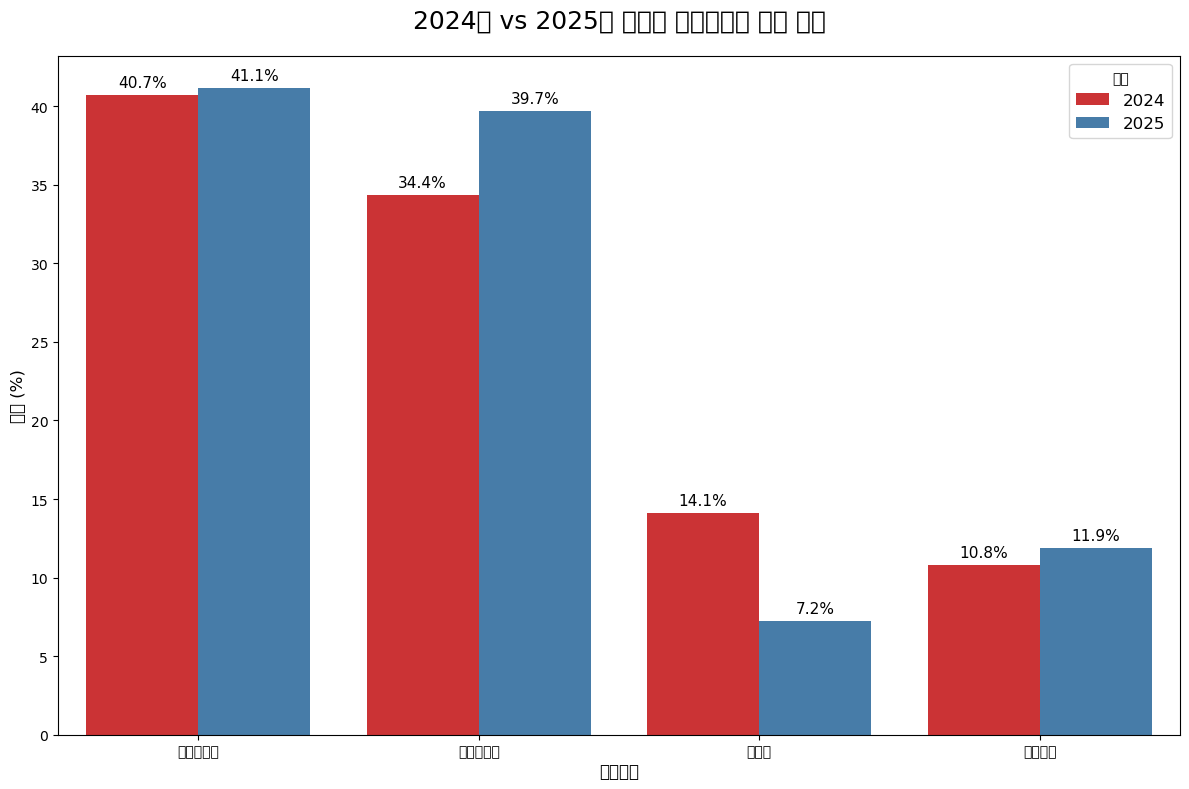

In [47]:
from scipy.stats import chi2_contingency
import pandas as pd
import matplotlib.pyplot as plt

# 검정 대상 데이터 2024년, 2025년 홍익대학교 건물용도
df_hongik_2024 = df_univ[df_univ['대학가'] == '홍익대']['건물용도']
df_hongik_2025 = df_hongik['건물용도']

counts_2024 = df_hongik_2024.value_counts()
counts_2025 = df_hongik_2025.value_counts()

contingency_table = pd.DataFrame({
    '2024': counts_2024,
    '2025': counts_2025
})

# 연도별 건물용도별 비율
# 2024년 비율 계산 (normalize=True 사용)
percents_2024 = df_hongik_2024.value_counts(normalize=True) * 100
df_perc_2024 = percents_2024.reset_index()
df_perc_2024.columns = ['건물용도', '비율']
df_perc_2024['연도'] = 2024 # '연도' 컬럼 추가

# 2025년 비율 계산 (normalize=True 사용)
percents_2025 = df_hongik_2025.value_counts(normalize=True) * 100
df_perc_2025 = percents_2025.reset_index()
df_perc_2025.columns = ['건물용도', '비율']
df_perc_2025['연도'] = 2025 # '연도' 컬럼 추가

# 검정 시작
# 빈도 표
contingency_table = contingency_table.transpose()
print(f'\n빈도 표')
print(contingency_table)

# 비율로 변환
contingency_table_prop = contingency_table.apply(
    lambda x: x/x.sum(),
    axis=1
)
print(f'\n비율로 변환')
print((contingency_table_prop * 100).round(2)) # 백분율로 출력

# 카이제곱 겁정
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n카이제곱 검정 결과")
print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

df_plot = pd.concat([df_perc_2024, df_perc_2025])
plt.figure(figsize=(12, 8)) # 캔버스 크기 조절
ax = sns.barplot(
    data=df_plot, 
    x='건물용도', 
    y='비율', 
    hue='연도', # '연도'별로 색상을 다르게 하여 그룹화
    palette='Set1' # 색상 팔레트
)

ax.set_title('2024년 vs 2025년 홍익대 건물용도별 비율 비교', fontsize=18, pad=20)
ax.set_xlabel('건물용도', fontsize=12)
ax.set_ylabel('비율 (%)', fontsize=12)
ax.legend(fontsize=12, title='연도', loc='upper right')

# 막대 위 수치 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11)

plt.tight_layout()
plt.show()


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/1093640504.py:15: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/1093640504.py:15: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/1093640504.py:15: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/1093640504.py:15: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/1093640504.py:15: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/1093640504.py:15: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout

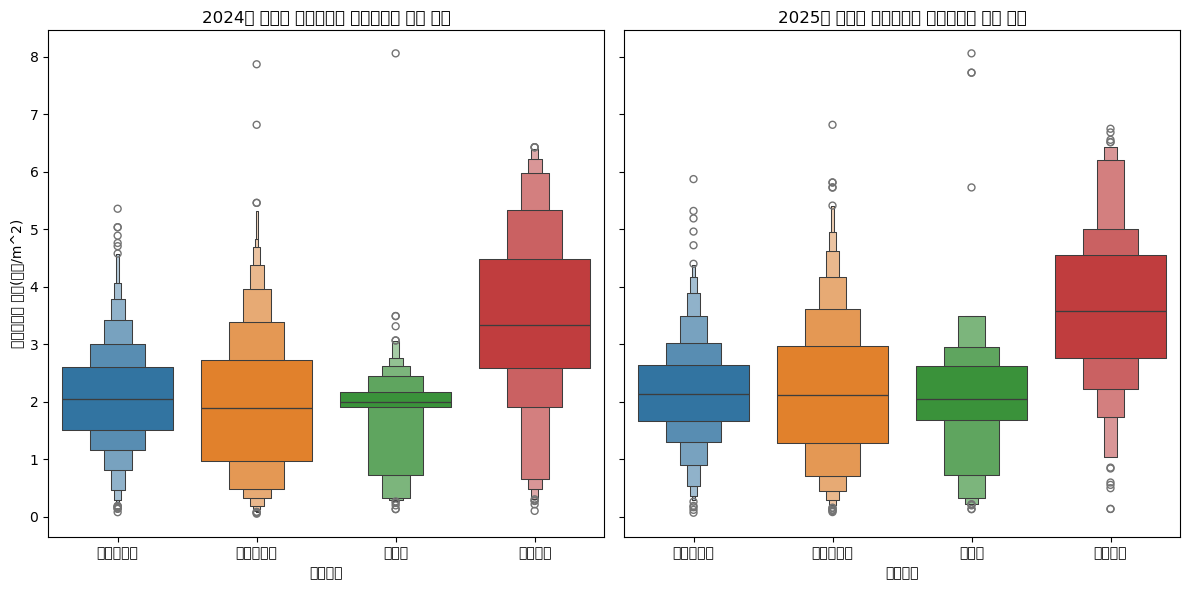

건물용도
아파트      1.910228
연립다세대    1.955908
단독다가구    2.080783
오피스텔     3.459660
Name: 단위면적당_월세, dtype: float64
건물용도
아파트      2.132811
단독다가구    2.174040
연립다세대    2.188281
오피스텔     3.695419
Name: 단위면적당_월세, dtype: float64


In [48]:
# 데이터프레임 준비
df_hongik_2024 = df_univ[df_univ['대학가'] == '홍익대']
df_hongik_2025 = df_hongik.copy()

# 건물용도별 단위면적당 월세 분포 시각화
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.boxenplot(x='건물용도', y='단위면적당_월세', data=df_hongik_2024, hue='건물용도', ax=ax[0])
ax[0].set_title('2024년 홍익대 건물용도별 단위면적당 월세 분포')
ax[0].set_ylabel('단위면적당 월세(만원/m^2)')

sns.boxenplot(x='건물용도', y='단위면적당_월세', data=df_hongik_2025, hue='건물용도', ax=ax[1])
ax[1].set_title('2025년 홍익대 건물용도별 단위면적당 월세 분포')
ax[1].set_ylabel('단위면적당 월세(만원/m^2)')

plt.tight_layout()
plt.show()

# 건물용도별 단위면적당 월세 평균 산출
mean_2024 = df_hongik_2024.groupby('건물용도')['단위면적당_월세'].mean().sort_values()
mean_2025 = df_hongik_2025.groupby('건물용도')['단위면적당_월세'].mean().sort_values()

print(mean_2024)
print(mean_2025)

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/268333188.py:28: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3100/268333188.py:28: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3100/268333188.py:28: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3100/268333188.py:28: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3100/268333188.py:28: UserWarning: 

--- 2025년 홍익대 월세 평균 비교 ---
아파트 평균: 2.13
단독다가구 평균: 2.17


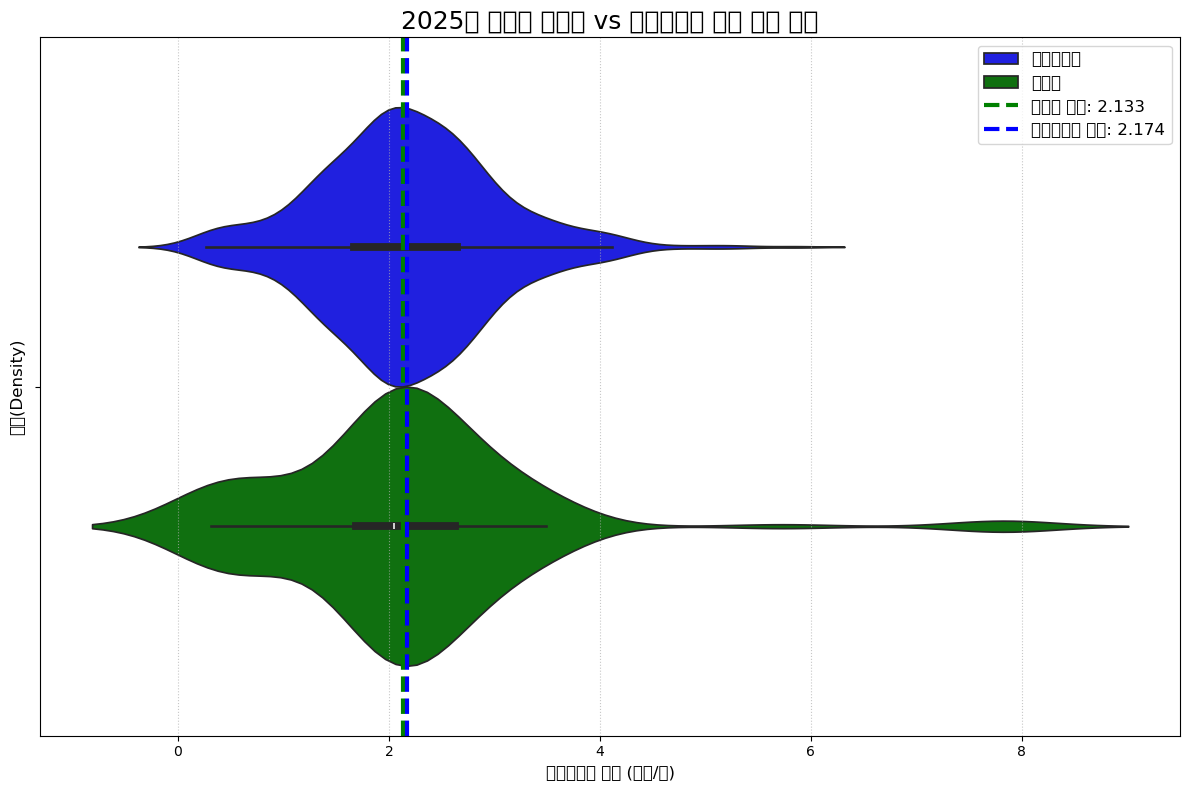

In [49]:
target_df = pd.DataFrame(df_hongik_2025[df_hongik_2025['건물용도'].isin(['아파트', '단독다가구'])])

apt_mean = target_df[target_df['건물용도'] == '아파트']['단위면적당_월세'].mean()
dandok_mean = target_df[target_df['건물용도'] == '단독다가구']['단위면적당_월세'].mean()

print(f"--- 2025년 홍익대 월세 평균 비교 ---")
print(f"아파트 평균: {apt_mean:.2f}")
print(f"단독다가구 평균: {dandok_mean:.2f}")

fig, ax = plt.subplots(figsize=(12, 8))

sns.violinplot(
    data=target_df,
    x='단위면적당_월세',
    hue='건물용도',
    ax=ax,
    palette={'아파트': 'green', '단독다가구': 'blue'}
)

ax.axvline(apt_mean, color='green', linestyle='--', linewidth=3, label=f'아파트 평균: {apt_mean:.3f}')
ax.axvline(dandok_mean, color='blue', linestyle='--', linewidth=3, label=f'단독다가구 평균: {dandok_mean:.3f}')

ax.set_title('2025년 홍익대 아파트 vs 단독다가구 월세 분포 비교', fontsize=18)
ax.set_xlabel('단위면적당 월세 (만원/㎡)', fontsize=12)
ax.set_ylabel('밀도(Density)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='x', linestyle=':', alpha=0.7)
fig.tight_layout()
plt.show()

### 가설 6: 2024년과 2025년의 서울시립대 월세 평균 비교
- 귀무가설($H_{0}$): $\mu_{2024, 시립대} = \mu_{2025, 시립대}$
- 대립가설($H_{A}$): $\mu_{2024, 시립대} \neq \mu_{2025, 시립대}$

2024년 거래량 수: 4640
2025년 거래량 수: 4567


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig

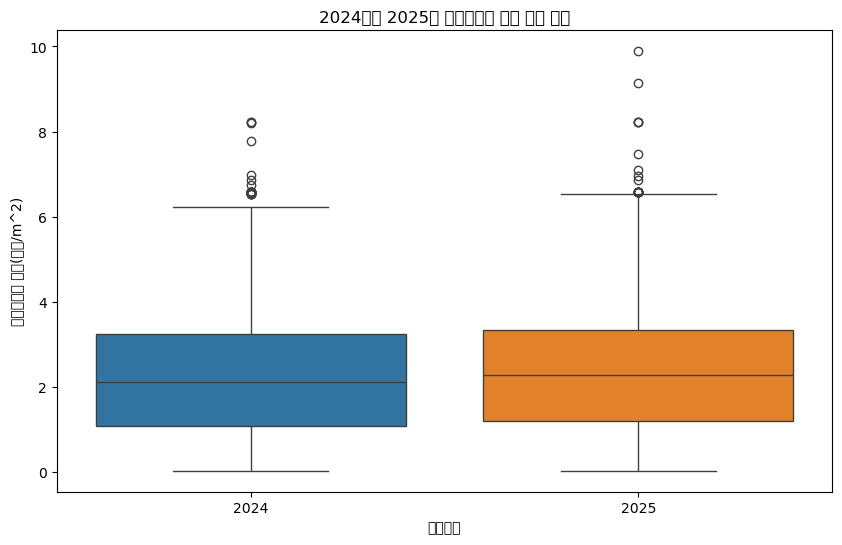

In [50]:
df_uos_2024 = df_univ[df_univ['대학가'] == '서울시립대'].copy()
df_uos_2025 = df_uos.copy()

df_uos_2024['접수연도'] = '2024'
df_uos_2025['접수연도'] = '2025'

# 데이터 수 확인
print(f'2024년 거래량 수: {df_uos_2024.shape[0]}')
print(f'2025년 거래량 수: {df_uos_2025.shape[0]}')

target_df = pd.concat([df_uos_2024[['접수연도', '단위면적당_월세']], df_uos_2025[['접수연도', '단위면적당_월세']]])

# 시각화
plt.figure(figsize=(10, 6))
sns.boxplot(data=target_df, x='접수연도', y='단위면적당_월세', hue='접수연도')
plt.title('2024년과 2025년 서울시립대 월세 분포 비교')
plt.xlabel('접수연도')
plt.ylabel('단위면적당 월세(만원/m^2)')
plt.show()

In [51]:
# 독립 표본 t검정, 두 그룹의 분산이 다르다고 해봤음
t_stat, p_value = stats.ttest_ind(df_uos_2024['단위면적당_월세'], df_uos_2025['단위면적당_월세'], equal_var=False)

print("\n--- 독립 표본 T검정 결과---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

print('둘의 차이는 유의미하다고 할 수 있다. (귀무가설 기각)')


--- 독립 표본 T검정 결과---
T-statistic: -4.4341
P-value: 0.0000
둘의 차이는 유의미하다고 할 수 있다. (귀무가설 기각)


# Machine Learning

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# 1. 분석 대상 데이터 준비
# 모델링에 사용할 변수 선정 (더 추가 가능)
features = ['접수년도', '임대면적', '보증금(만원)', '대학가', '건물용도']
target = '단위면적당_월세'

data_model = df_analysis[features + [target]].copy()

# 2. 범주형 변수는 One-Hot Encoding (대학가, 건물용도)
data_model = pd.get_dummies(data_model, columns=['대학가', '건물용도'], drop_first=True)

# 3. Train/Test Split (시계열 특성 고려)
# 2024년 데이터를 Test set으로, 그 이전(2018~2023)을 Train set으로 설정
train_data = data_model[data_model['접수년도'] < 2024]
test_data = data_model[data_model['접수년도'] == 2024]

X_train = train_data.drop(target, axis=1)
y_train = train_data[target]

X_test = test_data.drop(target, axis=1)
y_test = test_data[target]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 134494, Test samples: 28258


In [53]:
# 4. GradientBoostingRegressor로 학습

"""
What is GradientBoostingRegressor?
    - decision tree 기반의 앙상블 학습 기법.
    - 여러 개의 약한 학습기(주로 결정 트리)를 순차적으로 학습시켜 강력한 예측 모델을 만듦.
    - 각 트리는 이전 트리의 오차를 보완하는 방식으로 학습됨.

why GradientBoostingRegressor?
    0. 시계열 데이터에 강함: 시계열 특성을 반영한 학습 가능.
    1. 강력한 예측 성능: 여러 약한 학습기를 결합하여 복잡한 패턴을 학습.
    2. 과적합 방지: 학습률과 트리 깊이 조절로 과적합 위험 감소.
    3. 다양한 손실 함수 지원: 회귀, 분류 등 다양한 문제에 적용 가능.
    4. 변수 중요도 제공: 예측에 기여하는 변수 파악 가능.
"""

## n_estimators: 트리의 개수, learning_rate: 학습률, max_depth: 트리의 깊이
model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. 2024년 데이터로 성능 평가
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance (2024년 데이터 기준):")
print(f"RMSE: {rmse:.4f} (단위: 만원/㎡)")
print(f"R^2 Score: {r2:.4f}")

Model Performance (2024년 데이터 기준):
RMSE: 0.6400 (단위: 만원/㎡)
R^2 Score: 0.7217


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/tmp/ipykernel_3100/3676516778.py:95: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/3676516778.py:95: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/3676516778.py:95: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3100/3676516778.py:95: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

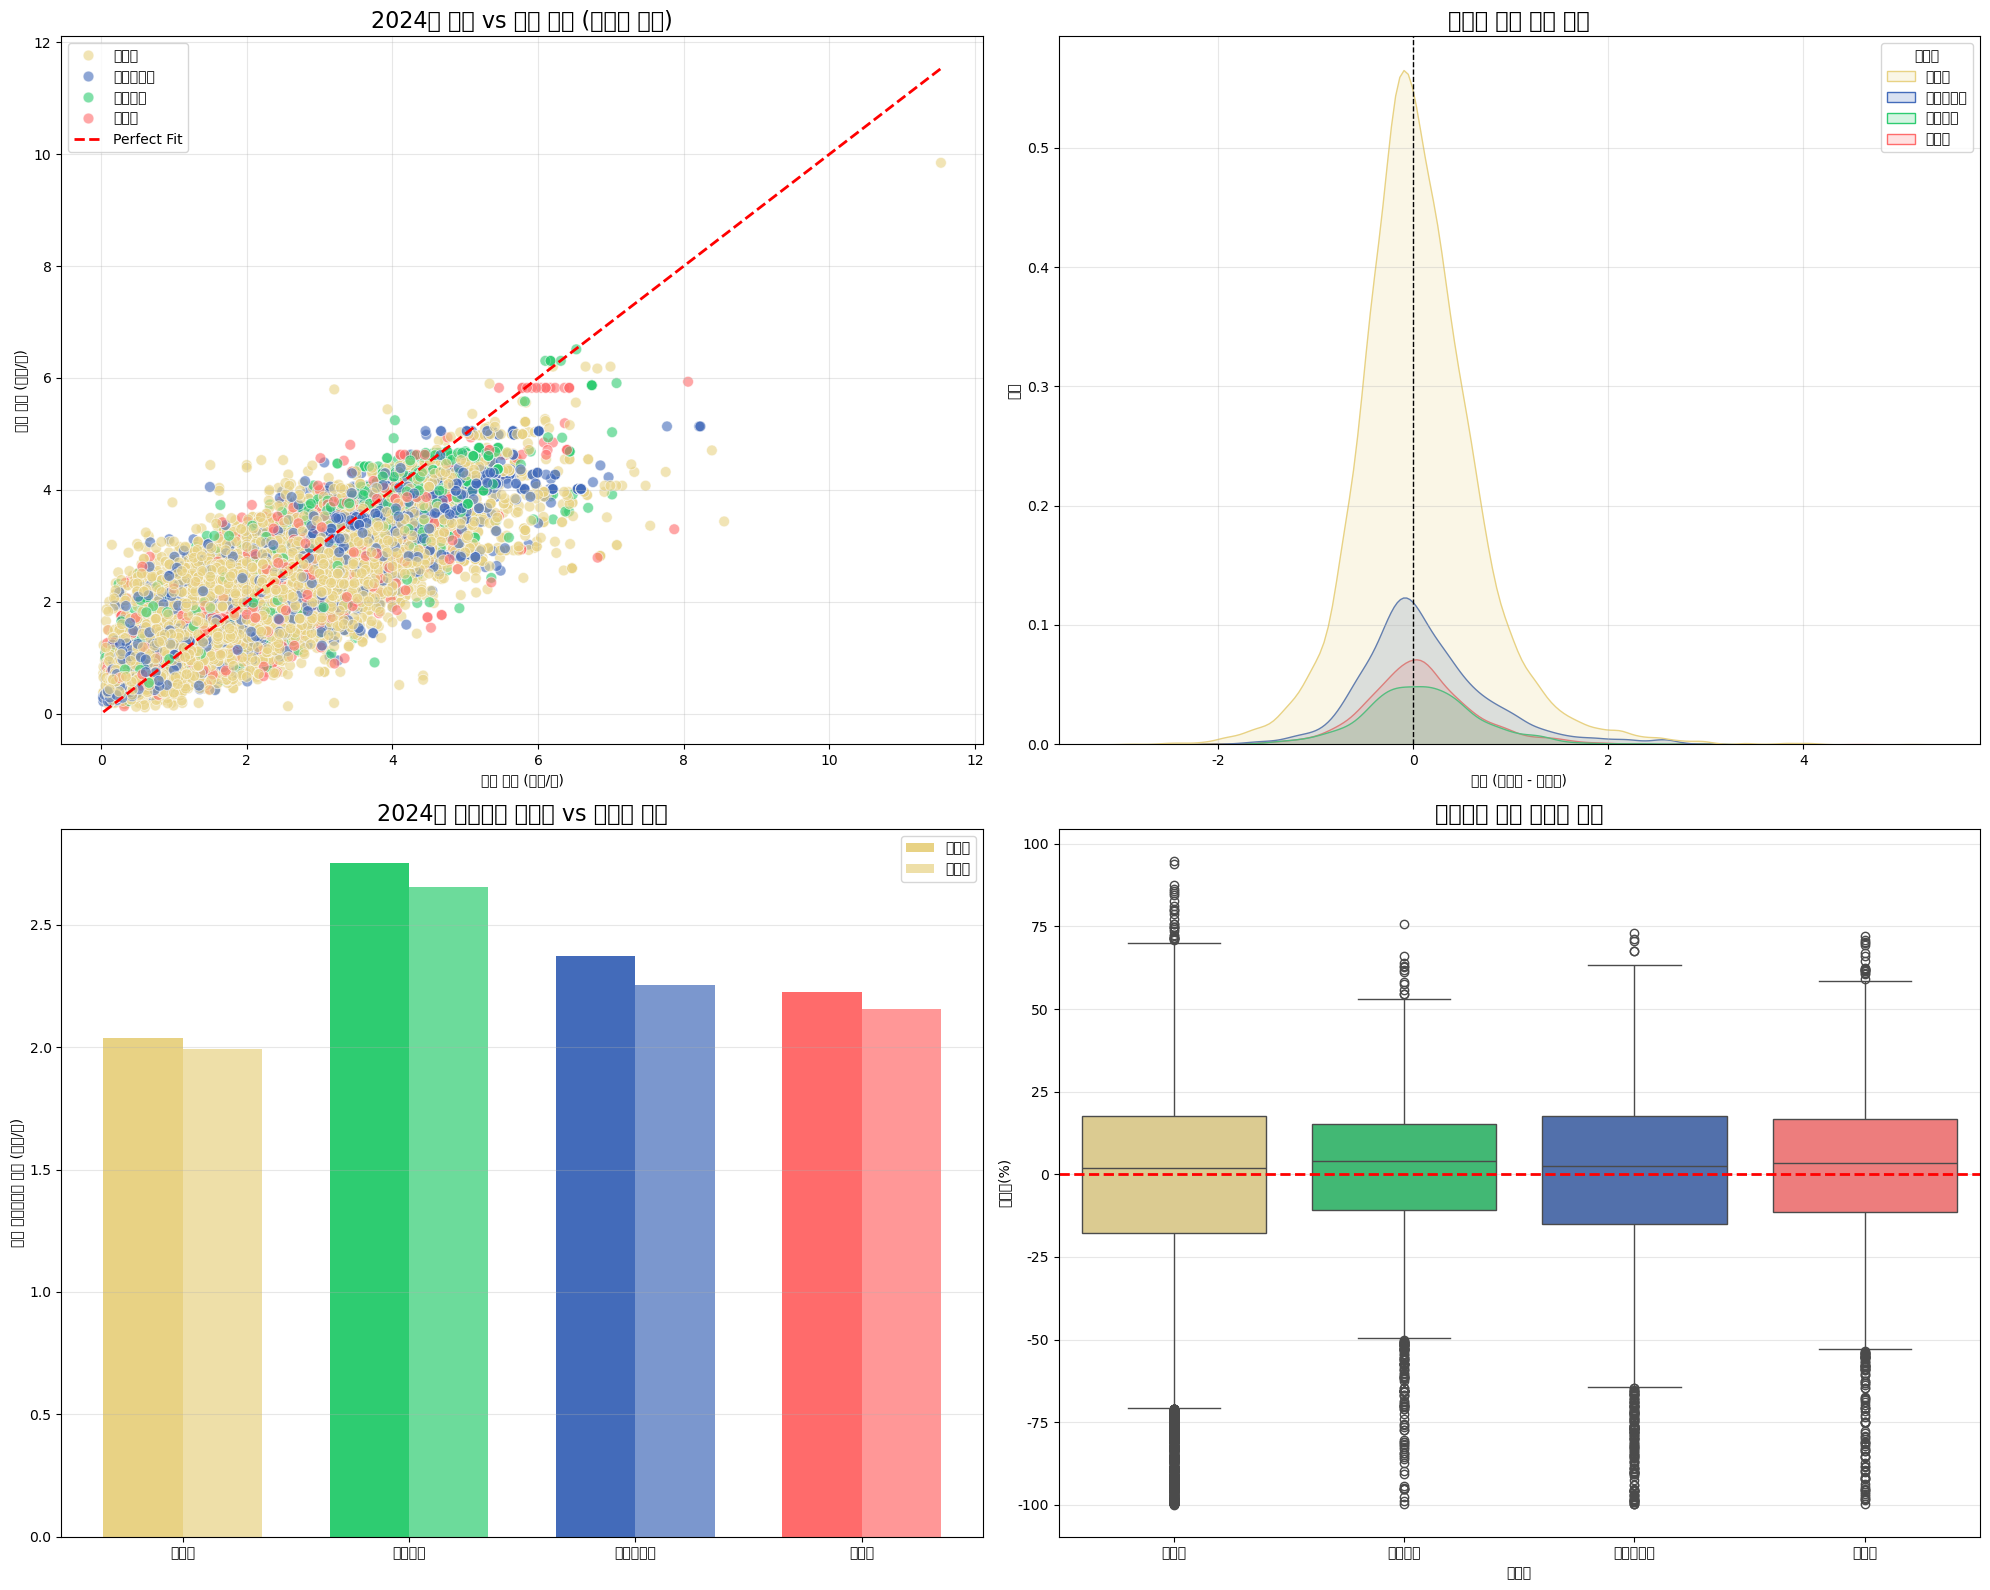

In [54]:

# ---------------------------------------------------------
# 1. 대학별 지정 색상 매핑
# ---------------------------------------------------------
# 서울대(노랑), 서울교대(초록), 서울시립대(파랑), 홍익대(빨강)
univ_palette = {
    '서울대': '#E8D284',
    '서울교대': '#2ECC71',
    '서울시립대': '#436BBA',
    '홍익대': '#FF6B6B'
}

# ---------------------------------------------------------
# 2. 데이터 준비
# ---------------------------------------------------------
comparison_df = test_data.copy()
comparison_df['실제값'] = y_test
comparison_df['예측값'] = y_pred
comparison_df['오차'] = comparison_df['실제값'] - comparison_df['예측값']
comparison_df['오차율(%)'] = (comparison_df['오차'] / comparison_df['실제값']) * 100
comparison_df['대학가'] = df_analysis.loc[comparison_df.index, '대학가']

# ---------------------------------------------------------
# 3. 시각화 (지정된 색상 적용)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# (1) 실제값 vs 예측값 산점도 (대학별 색상 적용)
# hue='대학가'를 통해 점마다 해당 대학의 색깔을 입힙니다.
sns.scatterplot(
    x='실제값', y='예측값', 
    data=comparison_df, 
    hue='대학가', 
    palette=univ_palette,  # ★ 지정된 색상 적용
    alpha=0.6, 
    s=60,
    ax=axes[0, 0]
)
# 기준선 (y=x)
min_val = min(comparison_df['실제값'].min(), comparison_df['예측값'].min())
max_val = max(comparison_df['실제값'].max(), comparison_df['예측값'].max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[0, 0].set_title('2024년 실제 vs 예측 가격 (대학별 색상)', fontsize=16)
axes[0, 0].set_xlabel('실제 가격 (만원/㎡)')
axes[0, 0].set_ylabel('예측 가격 (만원/㎡)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='upper left')

# (2) 오차(Residual) 분포 (대학별 KDE Plot)
# 대학별로 오차 분포가 어떻게 다른지 선 그래프(밀도함수)로 보여줍니다.
sns.kdeplot(
    data=comparison_df, 
    x='오차', 
    hue='대학가', 
    palette=univ_palette,  # ★ 지정된 색상 적용
    fill=True, 
    alpha=0.2, 
    ax=axes[0, 1]
)
axes[0, 1].axvline(x=0, color='black', linestyle='--', lw=1)
axes[0, 1].set_title('대학별 예측 오차 분포', fontsize=16)
axes[0, 1].set_xlabel('오차 (실제값 - 예측값)')
axes[0, 1].set_ylabel('밀도')
axes[0, 1].grid(True, alpha=0.3)

# (3) 2024년 예측 결과와 실제 비교 (막대 그래프)
mean_actual = comparison_df.groupby('대학가')['실제값'].mean()
mean_pred = comparison_df.groupby('대학가')['예측값'].mean()
bar_width = 0.35
indices = np.arange(len(mean_actual))
bars1 = axes[1, 0].bar(indices, mean_actual[univ_palette.keys()], bar_width, label='실제값', color=[univ_palette[univ] for univ in univ_palette.keys()], alpha=1.0)
bars2 = axes[1, 0].bar(indices + bar_width, mean_pred[  univ_palette.keys()], bar_width, label='예측값', color=[univ_palette[univ] for univ in univ_palette.keys()], alpha=0.7)
axes[1, 0].set_xticks(indices + bar_width / 2)
axes[1, 0].set_xticklabels(univ_palette.keys())
axes[1, 0].set_title('2024년 대학가별 실제값 vs 예측값 비교', fontsize=16)
axes[1, 0].set_ylabel('평균 단위면적당 월세 (만원/㎡)')
axes[1, 0].legend()
axes[1, 0].grid(True, axis='y', alpha=0.3)

# (4) 대학가별 오차율 Boxplot
# 오차율이 너무 큰 이상치 제외 (-100 ~ 100% 사이)
filtered_df = comparison_df[comparison_df['오차율(%)'].between(-100, 100)]

sns.boxplot(
    x='대학가', 
    y='오차율(%)', 
    data=filtered_df, 
    palette=univ_palette, # ★ 지정된 색상 적용
    ax=axes[1, 1],
    order=list(univ_palette.keys()) # 순서 고정
)
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].set_title('대학가별 예측 오차율 분포', fontsize=16)
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:17


--- 2025년 대학가별 단위면적당 월세 예측 결과 ---
     대학가  2025_예측_단위면적당_월세
0    서울대          1.727495
1  서울시립대          0.883445
2   서울교대          1.229103
3    홍익대          1.033119


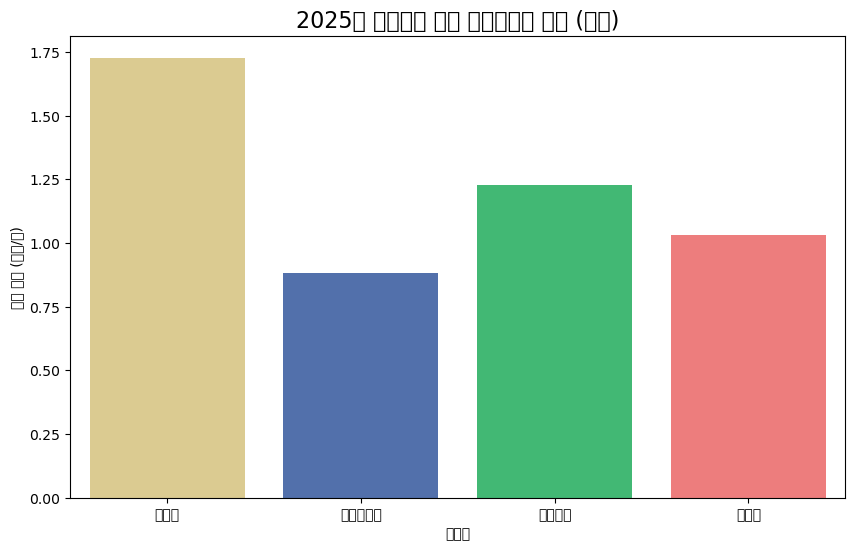

In [55]:
# 6. 2025년 예측을 위한 가상의 입력 데이터 생성 (2025년 데이터가 안불러와짐)

universities = ['서울대', '서울시립대', '서울교대', '홍익대']
future_predictions = []

univ_palette = {
    '서울대': '#E8D284',
    '서울교대': '#2ECC71',
    '서울시립대': '#436BBA',
    '홍익대': '#FF6B6B'
}

# 각 대학가별로 대표적인 샘플 데이터를 생성 (평균값 활용)
for univ in universities:
    # 해당 대학가의 평균 면적 및 보증금 계산
    univ_mean_area = df_analysis[df_analysis['대학가'] == univ]['임대면적'].mean()
    univ_mean_deposit = df_analysis[df_analysis['대학가'] == univ]['보증금(만원)'].mean()
    
    # 입력 데이터프레임 생성 (One-Hot Encoding 컬럼 포함)
    input_row = pd.DataFrame(0, index=[0], columns=X_train.columns)
    input_row['접수년도'] = 2025
    input_row['임대면적'] = univ_mean_area
    input_row['보증금(만원)'] = univ_mean_deposit
    
    # 해당 대학가 및 건물용도(예: 아파트나 원룸 등 대표값) 더미 변수 설정
    # 컬럼명이 '대학가_서울대' 와 같은 형식인지 확인 필요
    if f'대학가_{univ}' in input_row.columns:
        input_row[f'대학가_{univ}'] = 1
    
    # 예측 수행
    pred_price = model.predict(input_row)[0]
    future_predictions.append({'대학가': univ, '2025_예측_단위면적당_월세': pred_price})

# 결과 출력
df_future = pd.DataFrame(future_predictions)
print("\n--- 2025년 대학가별 단위면적당 월세 예측 결과 ---")
print(df_future)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='대학가', y='2025_예측_단위면적당_월세', data=df_future, palette=univ_palette)
plt.title('2025년 대학가별 예상 단위면적당 월세 (예측)', fontsize=16)
plt.ylabel('예상 월세 (만원/㎡)')
plt.show()

#### 대학가별 법정동별 20대 주민등록인구 데이터 추가

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = './Data'

# CSV 파일 검색
all_file_list = glob.glob(os.path.join(path, '20*.csv'))
exclude_file_list = ['./Data/2025.csv', './Data/2025_hs.csv']
file_list = [f for f in all_file_list if f not in exclude_file_list]

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

# 임대면적 전처리
df = df_combined.copy()
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도']
df = df[selected_columns]
df = df.dropna()
df = df[df['임대면적'] > 0]
q1 = df['임대면적'].quantile(0.25)
q3 = df['임대면적'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['임대면적'] >= lower_bound) & (df['임대면적'] <= upper_bound)]

# 임대료 전처리
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]

df = df[df['보증금(만원)'] > 0]

# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]

# 단위면적당 월세 계산
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 무한대 및 NaN 값 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df[df['대학가'] != ''].copy()

df_final = pd.read_csv('Data/Seoul_20s_pop_univ_mapped.csv')
df_final['접수년도'] = df_final['접수년도'].apply(float)
df_final = df_final.groupby(['접수년도', '대학가', '법정동명'])['20대 인구 합계'].sum().reset_index()

# 1. 분석 대상 데이터 준비
# 모델링에 사용할 변수 선정 (더 추가 가능)
features = ['접수년도', '임대면적', '보증금(만원)', '대학가', '건물용도', '법정동명']
target = '단위면적당_월세'

data_model = df_analysis[features + [target]].copy()

data_model = pd.merge(data_model, df_final, on=['접수년도', '대학가', '법정동명'], how='left')
data_model['20대 인구 합계'] = data_model['20대 인구 합계'].fillna(0)

print(f'최종 데이터 개수: {len(data_model)}')

univ_info = data_model['대학가']


# 2. 범주형 변수는 One-Hot Encoding (대학가, 건물용도)
data_model = pd.get_dummies(data_model, columns=['대학가', '건물용도', '법정동명'], drop_first=True)
print(data_model.head())    

# 3. Train/Test Split (시계열 특성 고려)
# 2024년 데이터를 Test set으로, 그 이전(2018~2023)을 Train set으로 설정
train_data = data_model[data_model['접수년도'] < 2024]
test_data = data_model[data_model['접수년도'] == 2024]

X_train = train_data.drop(target, axis=1)
y_train = train_data[target]

X_test = test_data.drop(target, axis=1)
y_test = test_data[target]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

## n_estimators: 트리의 개수, learning_rate: 학습률, max_depth: 트리의 깊이
model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. 2024년 데이터로 성능 평가
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance (2024년 데이터 기준):")
print(f"RMSE: {rmse:.4f} (단위: 만원/㎡)")
print(f"R^2 Score: {r2:.4f}")

찾은 CSV 파일 개수: 7
파일 목록: ['./Data/2022.csv', './Data/2018.csv', './Data/2019.csv', './Data/2020.csv', './Data/2021.csv', './Data/2024.csv', './Data/2023.csv']

통합된 데이터프레임 크기: (3557756, 23)
최종 데이터 개수: 162752
   접수년도   임대면적  보증금(만원)  단위면적당_월세  20대 인구 합계  대학가_서울대  대학가_서울시립대  대학가_홍익대  \
0  2022  18.50     4000  2.162162      51461     True      False    False   
1  2022  15.96    12500  0.375940      51461     True      False    False   
2  2022  20.00     1000  2.150000      51461     True      False    False   
3  2022  11.00      500  4.545455      54956     True      False    False   
4  2022  11.00      200  3.090909      54956     True      False    False   

   건물용도_아파트  건물용도_연립다세대  건물용도_오피스텔  법정동명_봉천동  법정동명_상수동  법정동명_서교동  법정동명_서초동  \
0     False       False      False      True     False     False     False   
1     False       False      False      True     False     False     False   
2     False       False      False      True     False     False     False   
3     False       Fa

# Why?

## Supply-Side Analysis

### data loading

In [58]:
file_path = './Data/서울시 건축물대장 총괄표제부.csv'
data = pd.read_csv(file_path, encoding='cp949', low_memory=False)

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19810 entries, 0 to 19809
Data columns (total 53 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   대지위치          19810 non-null  object 
 1   시군구코드명        19564 non-null  object 
 2   법정동코드명        19564 non-null  object 
 3   대지구분코드명       19810 non-null  object 
 4   주지번           19810 non-null  int64  
 5   부지번           19810 non-null  int64  
 6   특수지명          26 non-null     object 
 7   블록번호          9 non-null      object 
 8   로트번호          1 non-null      float64
 9   새주소도로코드명      12378 non-null  object 
 10  새주소법정동코드명     12378 non-null  object 
 11  새주소지상지하구분코드명  19655 non-null  object 
 12  새주소주지번        13423 non-null  float64
 13  새주소부지번        8166 non-null   float64
 14  건축물대장일련번호     19810 non-null  object 
 15  대장구분코드명       19799 non-null  object 
 16  대장종류코드명       19810 non-null  object 
 17  대지면적          12215 non-null  float64
 18  건축면적          16011 non-nu

In [60]:
data['기타용도내용']

0                                                       학교
1                                                   아파트,상가
2                                                      아파트
3                                              근린생활시설, 여인숙
4                                             아파트 및 근린생활시설
                               ...                        
19805    공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및...
19806                                숙박시설(판매,위락,문화및집회,운동등)
19807                                            공동주택(아파트)
19808                                           근린생활시설, 주택
19809                                             공동주택,아파트
Name: 기타용도내용, Length: 19810, dtype: object

In [61]:
selected_columns = ['허가일자', '새주소법정동코드명', '기타용도내용']
data = data[selected_columns]
data

,허가일자,새주소법정동코드명,기타용도내용
0,NaN,대현동,학교
1,1992-06-12,방화동,"아파트,상가"
2,1991-12-28,방화동,아파트
3,NaN,구로동,"근린생활시설, 여인숙"
4,NaN,신월동,아파트 및 근린생활시설
...,...,...,...
19805,2014-09-11,전농동,"공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및..."
19806,1986-06-02,잠실동,"숙박시설(판매,위락,문화및집회,운동등)"
19807,2004-12-24,강일동,공동주택(아파트)
19808,NaN,NaN,"근린생활시설, 주택"


In [62]:
data.isnull().sum()
data = data.dropna()
data = data.copy()


In [63]:
# '허가일자'를 날짜 형식으로 변환합니다.
# errors='coerce'는 변환할 수 없는 값이 있을 경우 오류 대신 결측치(NaT)로 만듭니다.
data['허가일자'] = pd.to_datetime(data['허가일자'], errors='coerce')

# 날짜에서 '연도'만 추출하여 새 컬럼을 만듭니다.
data['허가연도'] = data['허가일자'].dt.year

# 변환에 실패했거나 연도가 없는 데이터는 분석에서 제외합니다.
data = data.dropna(subset=['허가연도'])

# 연도를 정수형으로 변환합니다 (예: 2020.0 -> 2020).
data['허가연도'] = data['허가연도'].astype(int)

print("'허가연도' 컬럼 생성 완료:")
print(data[['허가일자', '허가연도']].head())

data

'허가연도' 컬럼 생성 완료:
         허가일자  허가연도
1  1992-06-12  1992
2  1991-12-28  1991
10 2003-12-30  2003
18 2015-09-11  2015
21 2022-02-24  2022


,허가일자,새주소법정동코드명,기타용도내용,허가연도
1,1992-06-12,방화동,"아파트,상가",1992
2,1991-12-28,방화동,아파트,1991
10,2003-12-30,장지동,아파트,2003
18,2015-09-11,항동,도시형생활주택(원룸형),2015
21,2022-02-24,공항동,공동주택(아파트),2022
...,...,...,...,...
19804,2018-10-08,원효로1가,"공동주택,제1종근린생활시설,문화및집회시설",2018
19805,2014-09-11,전농동,"공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및...",2014
19806,1986-06-02,잠실동,"숙박시설(판매,위락,문화및집회,운동등)",1986
19807,2004-12-24,강일동,공동주택(아파트),2004


In [64]:
# 1. 분류 규칙을 담은 함수를 정의합니다.
def classify_building_type(text):
    # text가 비어있는 경우(NaN)를 대비한 예외 처리
    if pd.isna(text):
        return '기타'
    
    # 1순위: '아파트' 확인
    if '아파트' in text:
        return '아파트'
    # 2순위: '오피스텔' 확인
    elif '오피스텔' in text:
        return '오피스텔'
    # 3순위: '다세대' 또는 '다가구' 확인
    elif '다세대' in text or '다가구' in text:
        return '다세대/다가구'
    # 그 외
    else:
        return '기타'

# 2. '기타용도내용' 컬럼에 함수를 적용하여 '세부용도'라는 새 컬럼을 생성합니다.
data['세부용도'] = data['기타용도내용'].apply(classify_building_type)

# 3. 분석에 필요한 주거 형태만 필터링합니다.
target_types = ['아파트', '오피스텔', '다세대/다가구']
analysis_data = data[data['세부용도'].isin(target_types)].copy()

# --- 결과 확인 ---
print("--- 분류 결과 (상위 5개) ---")
print(analysis_data[['기타용도내용', '세부용도']].head())

print("\n--- 세부용도별 데이터 개수 ---")
print(analysis_data['세부용도'].value_counts())

--- 분류 결과 (상위 5개) ---
       기타용도내용 세부용도
1      아파트,상가  아파트
2         아파트  아파트
10        아파트  아파트
21  공동주택(아파트)  아파트
23        아파트  아파트

--- 세부용도별 데이터 개수 ---
세부용도
아파트        1254
다세대/다가구     956
오피스텔        118
Name: count, dtype: int64


In [65]:
import pandas as pd


# 2. .map() 함수에 사용하기 편하도록 딕셔너리를 역으로 만듭니다.
dong_to_univ_map = {dong: univ for univ, dongs in univ_dong_map.items() for dong in dongs}

# 3. .map() 함수를 사용하여 '대학가' 컬럼을 한 번에 생성합니다.
data['대학가'] = data['새주소법정동코드명'].map(dong_to_univ_map)

# 4. '대학가' 이름이 할당되지 않은(분석 대상이 아닌) 행들을 제거하고,
#    분석용 데이터프레임을 복사본(.copy())으로 만듭니다.
analysis_data = data.dropna(subset=['대학가']).copy()


# --- 최종 결과 확인 ---
print("--- 최종 분석용 데이터 정보 ---")
analysis_data.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(analysis_data['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 ---")
# '새주소법정동코드명'이 '대학가'에 올바르게 매칭되었는지 확인합니다.
print(analysis_data[['새주소법정동코드명', '대학가']].head())

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 81 to 19809
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   허가일자       239 non-null    datetime64[ns]
 1   새주소법정동코드명  239 non-null    object        
 2   기타용도내용     239 non-null    object        
 3   허가연도       239 non-null    int64         
 4   세부용도       239 non-null    object        
 5   대학가        239 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 13.1+ KB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      132
서울교대      57
서울시립대     29
홍익대       21
Name: count, dtype: int64

--- 최종 데이터 샘플 ---
    새주소법정동코드명    대학가
81        서교동    홍익대
236      답십리동  서울시립대
422       서초동   서울교대
529       서초동   서울교대
852       신림동    서울대


In [66]:
# '허가연도', '대학가', '세부용도'를 기준으로 신축 허가 건수를 집계합니다.
supply_trend = analysis_data.groupby(['허가연도', '대학가', '세부용도']).size().reset_index(name='신축허가건수')

print("--- 연도별/대학가별/유형별 신축 허가 건수 집계 결과 ---")
print(supply_trend.head(10))

--- 연도별/대학가별/유형별 신축 허가 건수 집계 결과 ---
   허가연도  대학가     세부용도  신축허가건수
0  1983  서울대       기타       2
1  1983  홍익대       기타       1
2  1991  서울대      아파트       1
3  1992  서울대      아파트       1
4  1993  서울대  다세대/다가구       2
5  1994  서울대       기타       2
6  1994  홍익대       기타       1
7  1994  홍익대  다세대/다가구       2
8  1995  서울대       기타       2
9  1996  서울대       기타       1


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:17

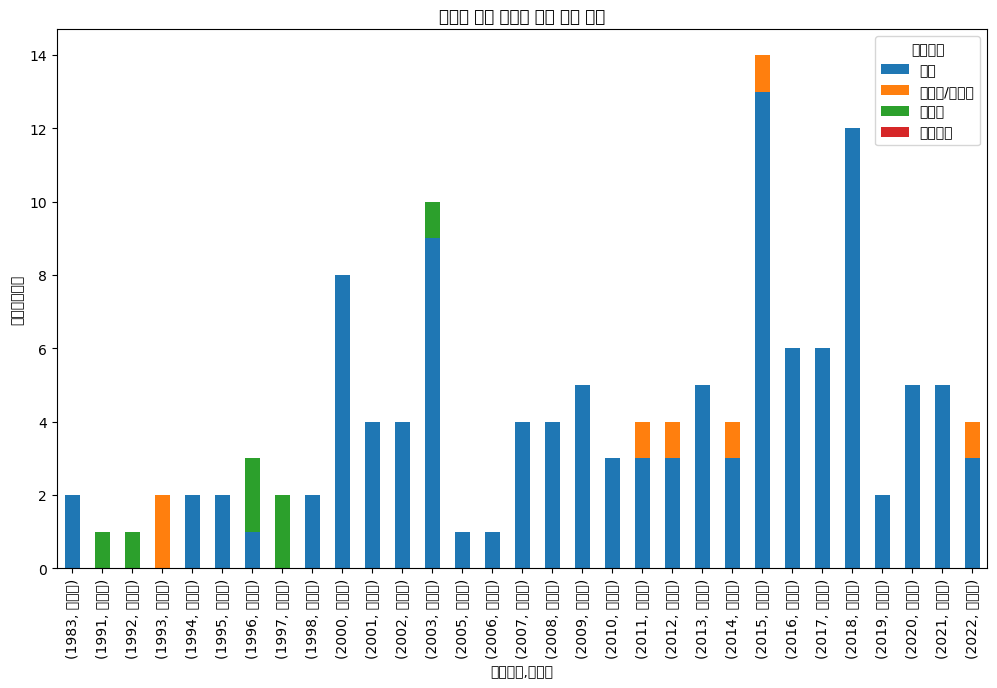

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3

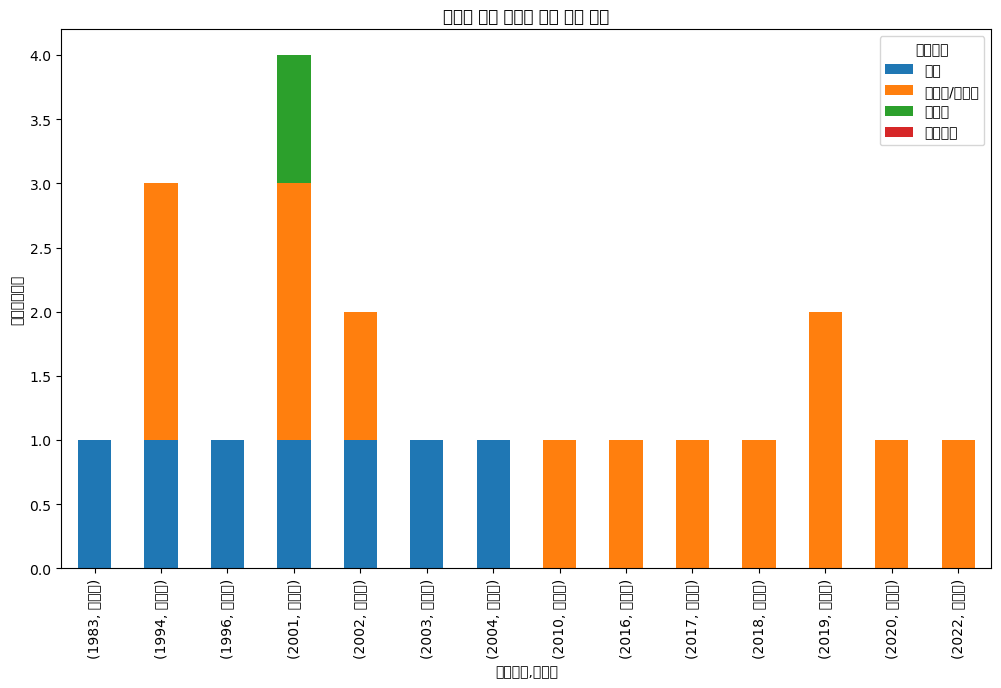

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54728 (\N{HANGUL SYLLABLE HEO}) missing from font(s) DejaVu Sans.
  fig.

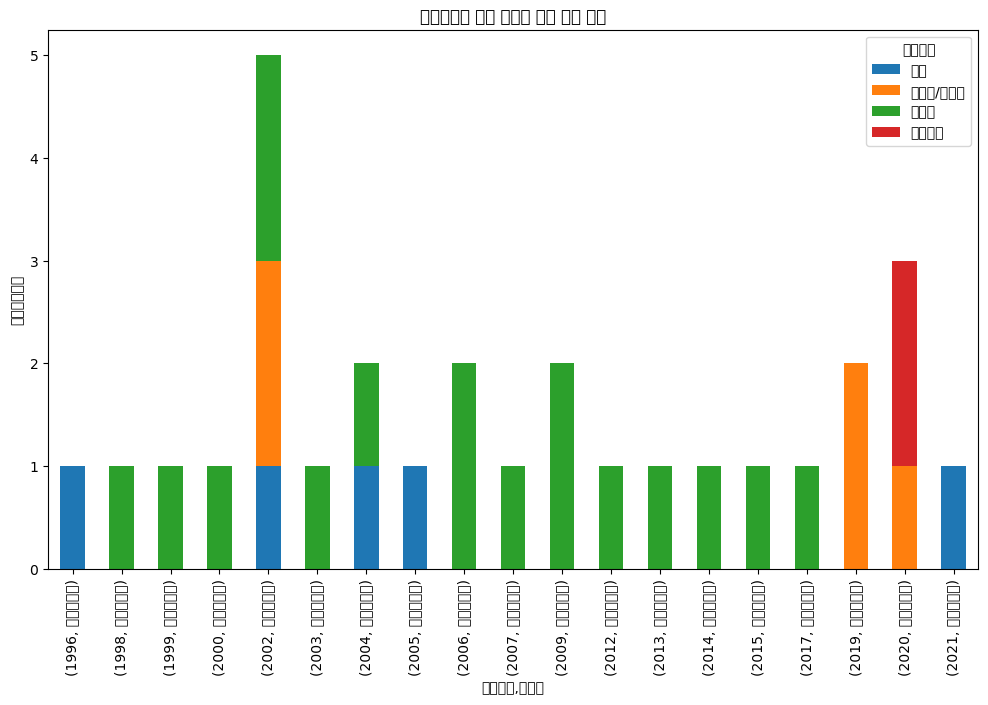

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/miniconda3/envs/uos_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54728 (\N{HANGUL SYLLABLE HEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hs/mi

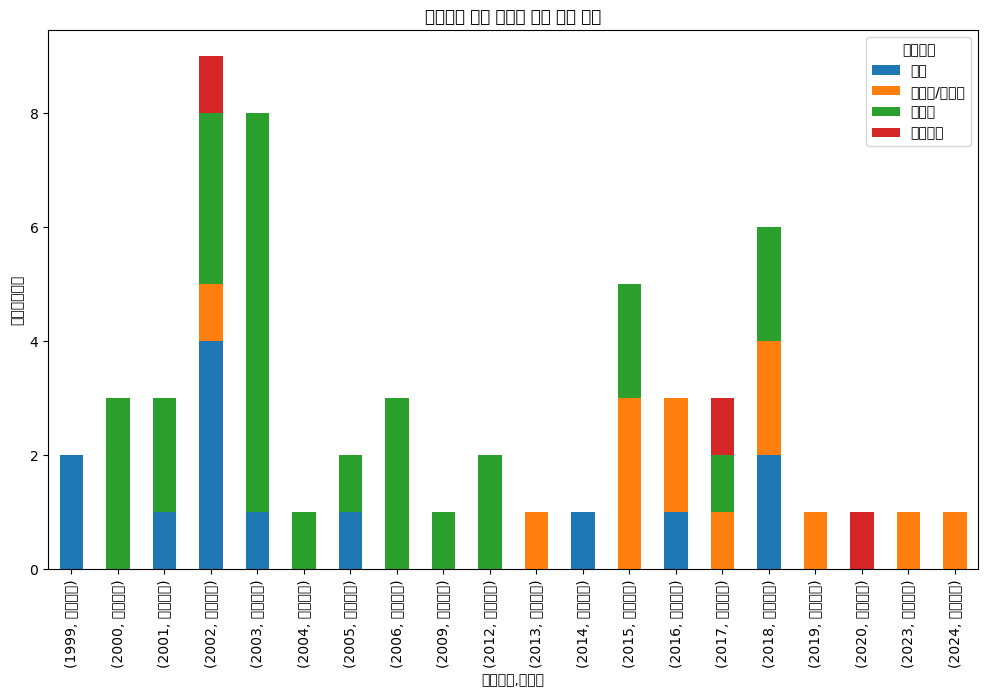

In [67]:
# 시각화를 위해 데이터를 피벗(pivot)합니다.
supply_pivot = supply_trend.pivot_table(index=['허가연도', '대학가'], 
                                        columns='세부용도', 
                                        values='신축허가건수',
                                        fill_value=0)

# 각 대학가별로 누적 막대그래프 그리기
for univ in supply_pivot.index.get_level_values('대학가').unique():
    supply_pivot.loc[(slice(None), univ), :].plot(
        kind='bar', 
        stacked=True, 
        figsize=(12, 7),
        title=f'{univ} 인근 연도별 신축 주택 유형'
    )
    plt.ylabel('신축허가건수')
    plt.show()

In [68]:
import matplotlib.font_manager as fm

# 1. 시스템에 있는 모든 폰트 파일을 훑어봅니다.
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')

# 2. 파일 경로에 'apple'이나 'gothic'이 들어간 폰트가 있는지 찾아서 '진짜 이름'을 출력합니다.
print("검색된 폰트 목록:")
found = False
for f_path in font_list:
    if 'apple' in f_path.lower() or 'gothic' in f_path.lower():
        # 폰트 파일에서 내부 이름(name) 정보를 가져옵니다.
        fp = fm.FontProperties(fname=f_path)
        print(f"파일 경로: {f_path} \n -> 인식된 이름(Family Name): {fp.get_name()}")
        found = True

if not found:
    print("Apple이나 Gothic 관련 폰트 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")

검색된 폰트 목록:
파일 경로: /usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf 
 -> 인식된 이름(Family Name): NanumGothicCoding
파일 경로: /usr/share/fonts/truetype/nanum/NanumGothicBold.ttf 
 -> 인식된 이름(Family Name): NanumGothic
파일 경로: /usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf 
 -> 인식된 이름(Family Name): NanumBarunGothic
파일 경로: /usr/share/fonts/opentype/urw-base35/URWGothic-DemiOblique.otf 
 -> 인식된 이름(Family Name): URW Gothic
파일 경로: /usr/share/fonts/truetype/apple/apple-gothic.ttf 
 -> 인식된 이름(Family Name): AppleGothic
파일 경로: /usr/share/fonts/opentype/urw-base35/URWGothic-Demi.otf 
 -> 인식된 이름(Family Name): URW Gothic
파일 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf 
 -> 인식된 이름(Family Name): NanumGothic
파일 경로: /usr/share/fonts/opentype/urw-base35/URWGothic-BookOblique.otf 
 -> 인식된 이름(Family Name): URW Gothic
파일 경로: /usr/share/fonts/opentype/urw-base35/URWGothic-Book.otf 
 -> 인식된 이름(Family Name): URW Gothic
파일 경로: /usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf 
 -> 인식된 이름(Fam